In [4]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/home/icb/dominik.klein/git_repos/ot_pert_new/fig_4/sciplex/wandb_export_2025-09-12T10_06_00.567+02_00.csv")

In [3]:
df.head()

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,dataset.dataset_path,dataset.perturbation_covariate_reps.drug,...,pca_decoded_ood_1_r_squared_mean,pca_decoded_ood_2_e_distance_mean,pca_decoded_ood_2_mmd_mean,pca_decoded_ood_2_r_squared_mean,pca_decoded_ood_3_e_distance_mean,pca_decoded_ood_3_mmd_mean,pca_decoded_ood_3_r_squared_mean,pca_decoded_ood_4_e_distance_mean,pca_decoded_ood_4_mmd_mean,pca_decoded_ood_4_r_squared_mean
0,soft-jazz-7313,finished,-,NaN,NaN,2025-09-12T02:52:20.000Z,4971,NaN,NaN,NaN,...,0.926246,7.311144,0.022736,0.882674,10.343359,0.030755,0.854293,29.986572,0.081141,0.626136
1,whole-rain-7400,finished,-,NaN,NaN,2025-09-12T05:27:54.000Z,4398,NaN,NaN,NaN,...,0.925163,7.568662,0.023331,0.879397,10.346408,0.030874,0.855436,30.791508,0.083663,0.618348
2,colorful-shape-6435,finished,-,NaN,NaN,2025-09-10T20:10:16.000Z,3944,NaN,NaN,NaN,...,0.923155,7.755212,0.023881,0.875593,10.526717,0.031430,0.852235,30.188789,0.082537,0.625440
3,apricot-shape-7434,crashed,-,NaN,NaN,2025-09-12T06:54:21.000Z,3541,NaN,NaN,NaN,...,0.911180,7.920463,0.024401,0.869842,10.625454,0.031623,0.847624,28.681353,0.080089,0.635389
4,daily-voice-7081,finished,-,NaN,NaN,2025-09-11T18:04:29.000Z,3118,NaN,NaN,NaN,...,0.920116,7.893106,0.024448,0.871762,10.658997,0.032085,0.847712,30.635206,0.084014,0.614597


In [6]:
df.columns

Index(['Name', 'State', 'Notes', 'User', 'Tags', 'Created', 'Runtime', 'Sweep',
       'dataset.dataset_path', 'dataset.perturbation_covariate_reps.drug',
       'dataset.perturbation_covariate_reps.drugs',
       'dataset.perturbation_covariates.dose',
       'dataset.perturbation_covariates.drug',
       'dataset.perturbation_covariates.drugs',
       'dataset.sample_covariate_reps.cell_line', 'dataset.sample_covariates',
       'dataset.split', 'dataset.split_covariates', 'dataset.wandb_project',
       'logger.group', 'logger.log_model', 'logger.offline', 'logger.project',
       'model.cond_output_dropout', 'model.condition_embedding_dim',
       'model.condition_mode', 'model.conditioning', 'model.decoder_dims',
       'model.decoder_dropout', 'model.ema', 'model.embedding_type',
       'model.epsilon', 'model.flow_noise', 'model.flow_type',
       'model.hidden_dims', 'model.hidden_dropout',
       'model.layer_norm_before_concatenation', 'model.layers_after_pool.dims',
       '

In [8]:
vars = ["model.cond_output_dropout",
"model.condition_embedding_dim",
"model.conditioning",
"model.decoder_dims",
"model.decoder_dropout",
"model.ema",
"model.embedding_type",
"model.epsilon",
"model.flow_noise",
"model.flow_type",
"model.hidden_dims",
"model.layers_after_pool.dims",
"model.layers_after_pool.dropout_rate",
"model.learning_rate",
"model.linear_projection_before_concatenation",
"model.multi_steps",
"model.pooling",
"model.regularization",
"model.time_encoder_dims",
"model.time_max_period",
"training.num_iterations"]

In [ ]:
cols = ["ood_1_e_distance_mean", "ood_2_e_distance_mean", "ood_3_e_distance_mean", "ood_4_e_distance_mean"]
for var in vars:
    sns.boxplot(df, y=cols, x=df[var].unique())

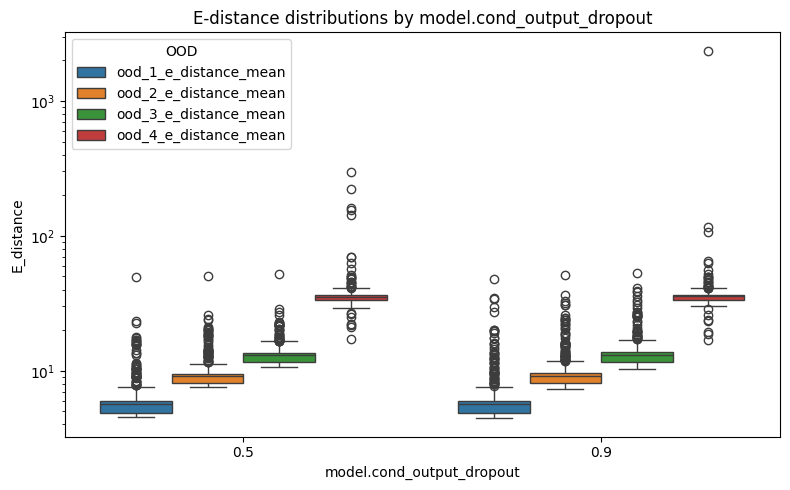

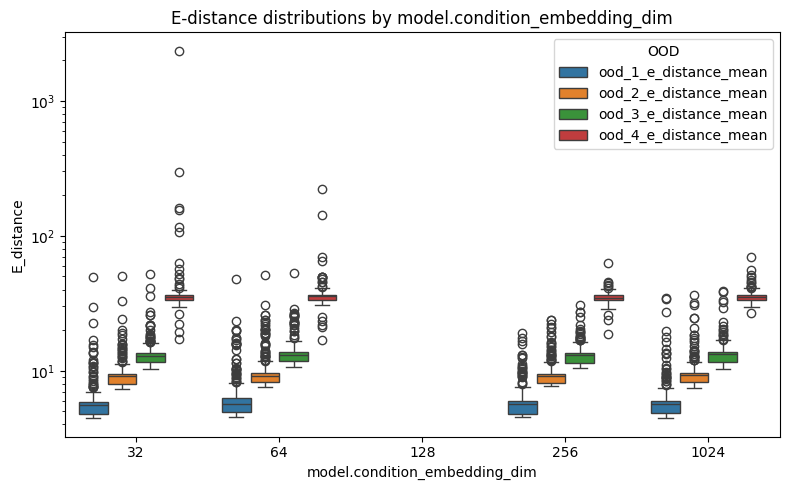

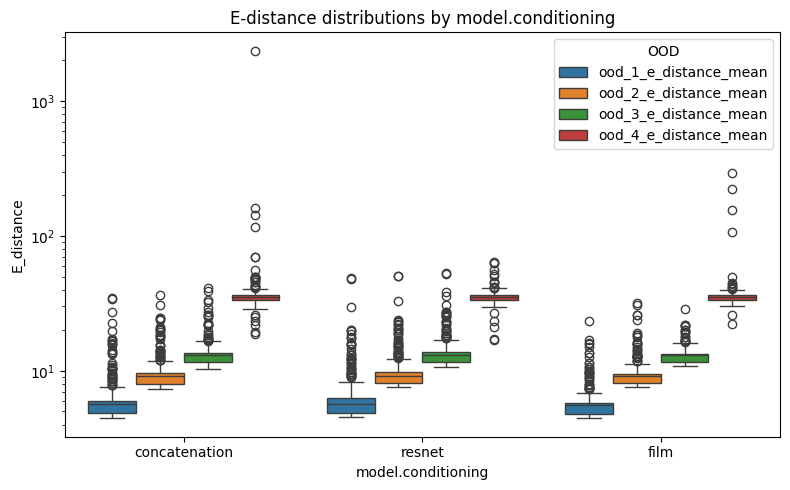

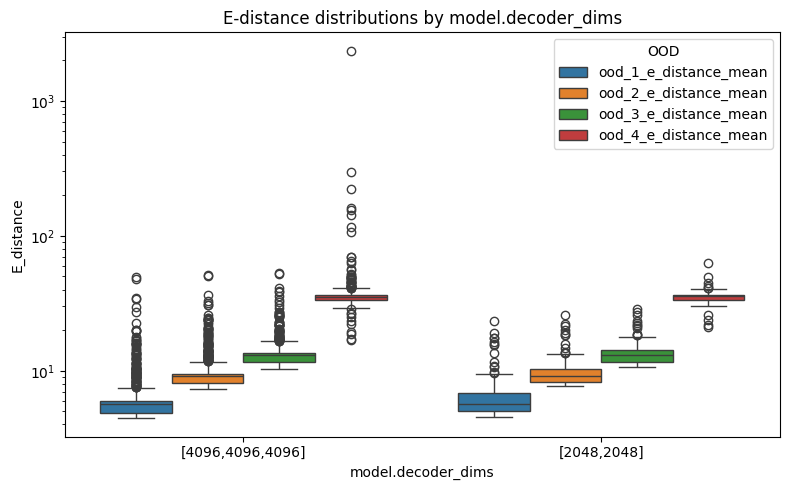

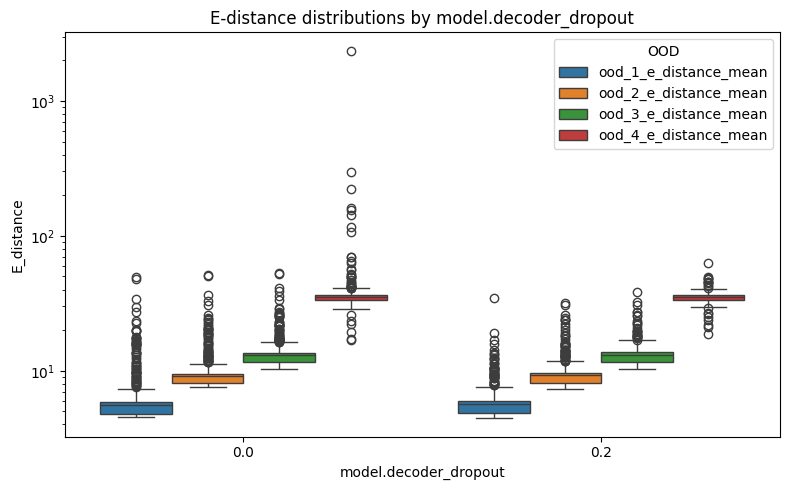

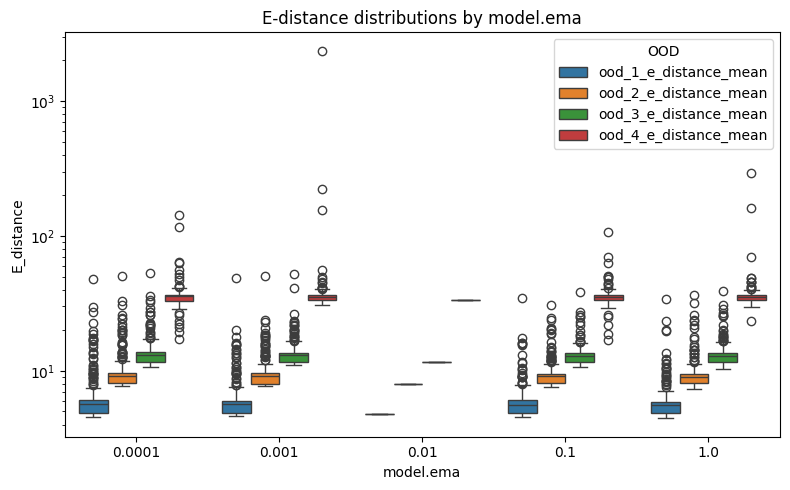

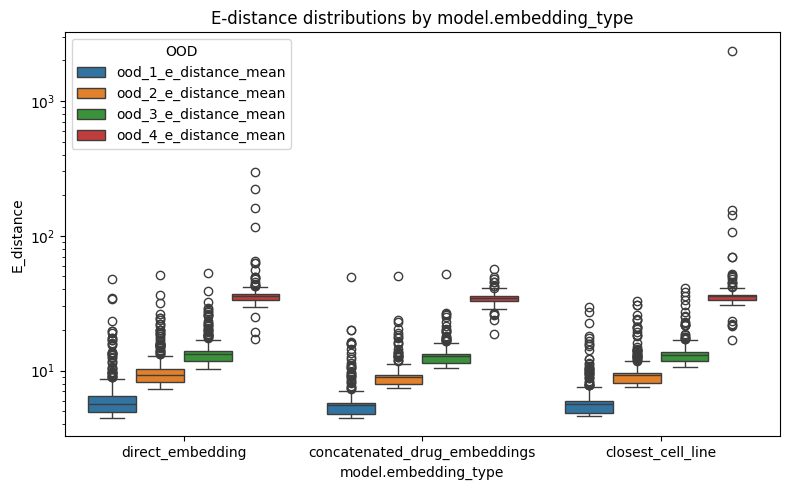

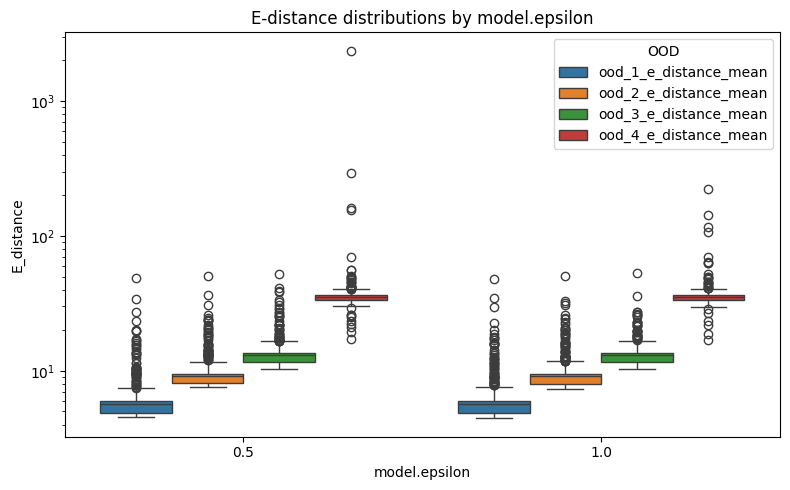

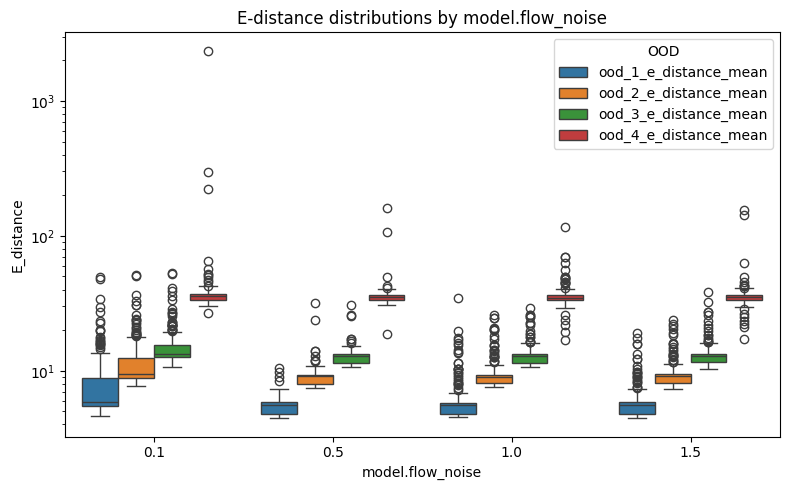

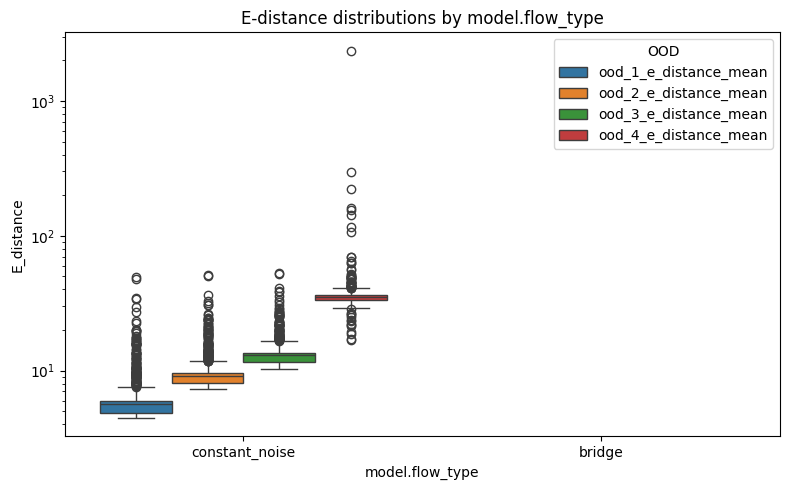

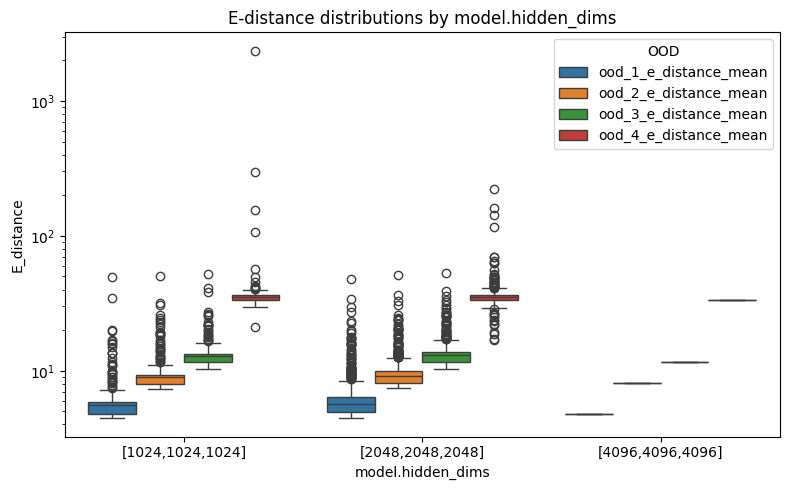

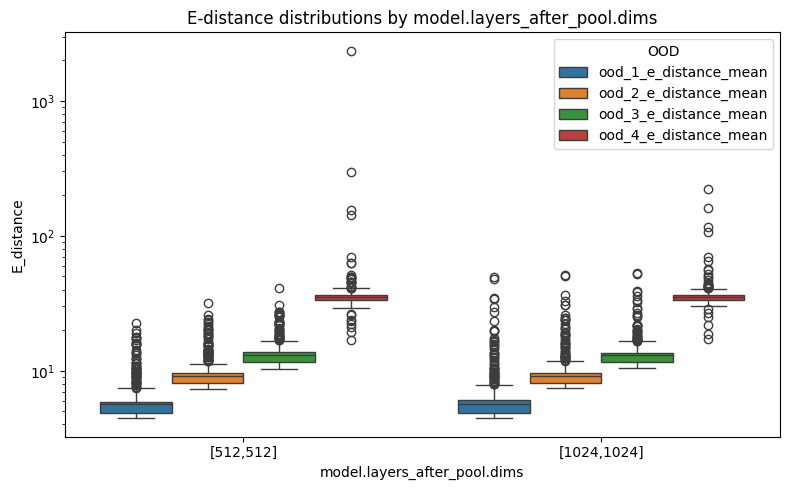

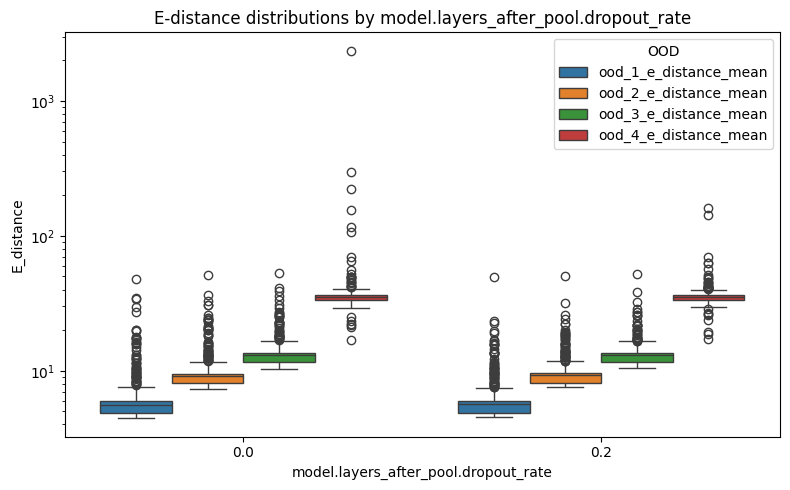

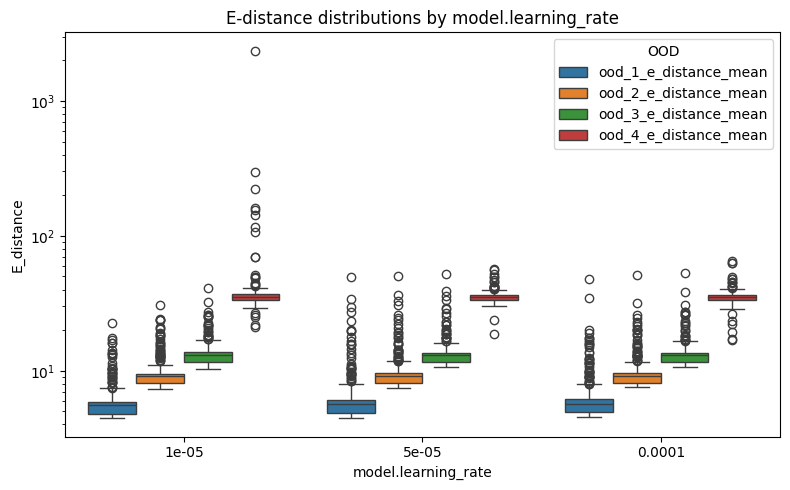

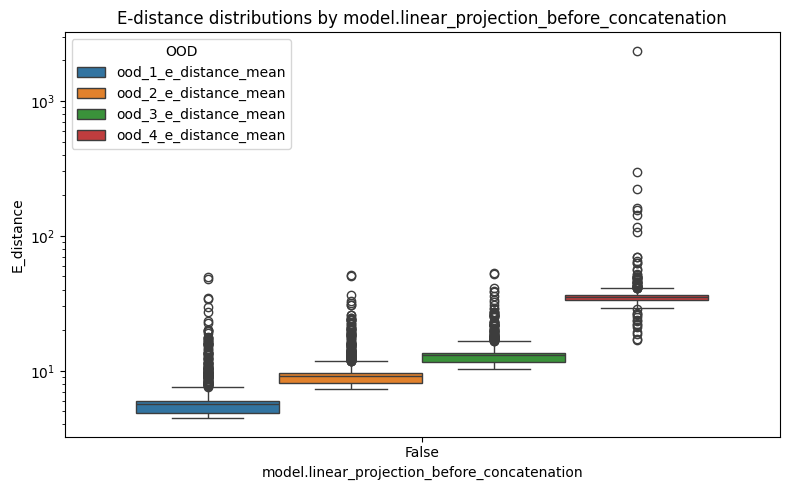

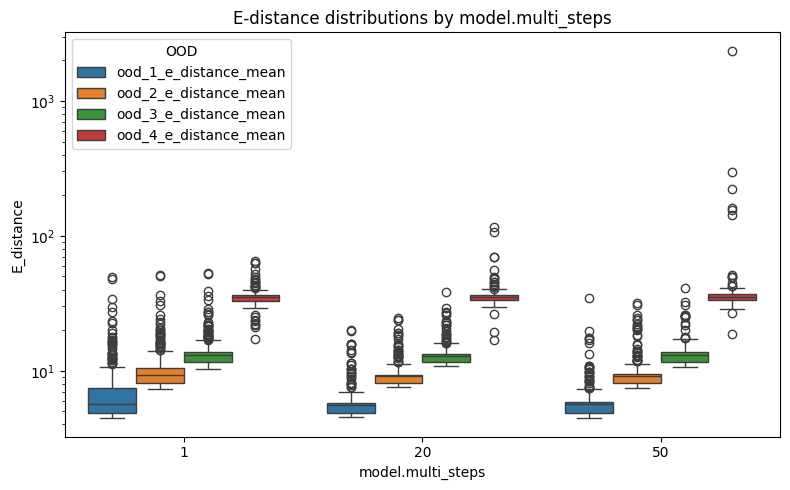

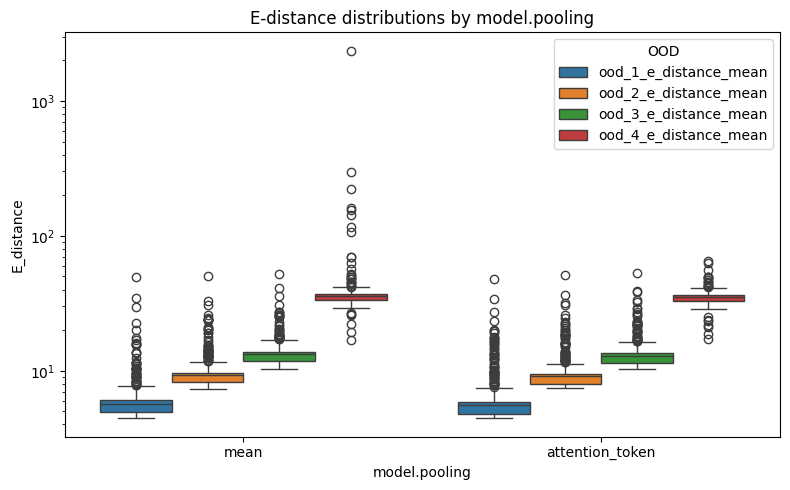

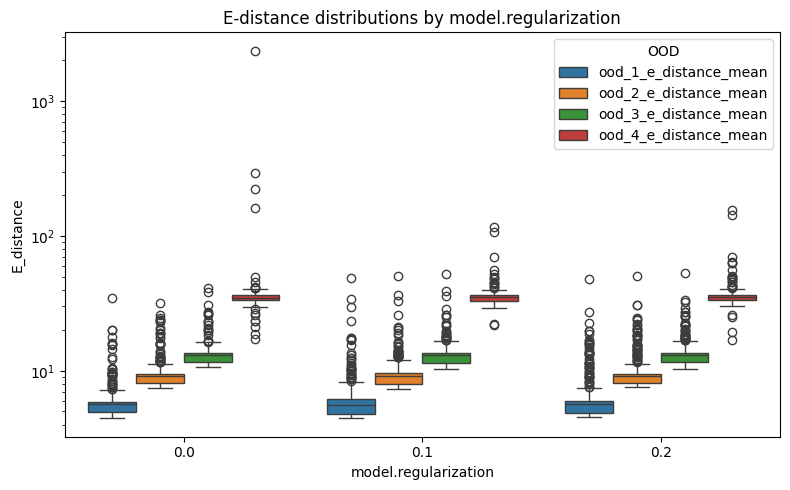

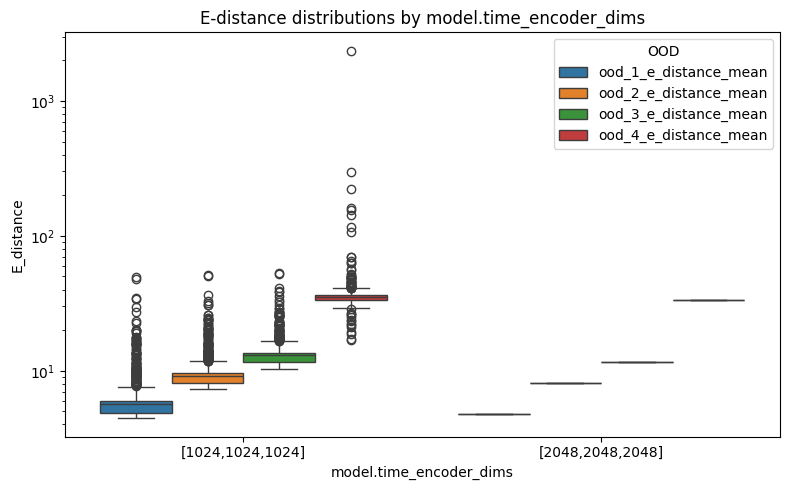

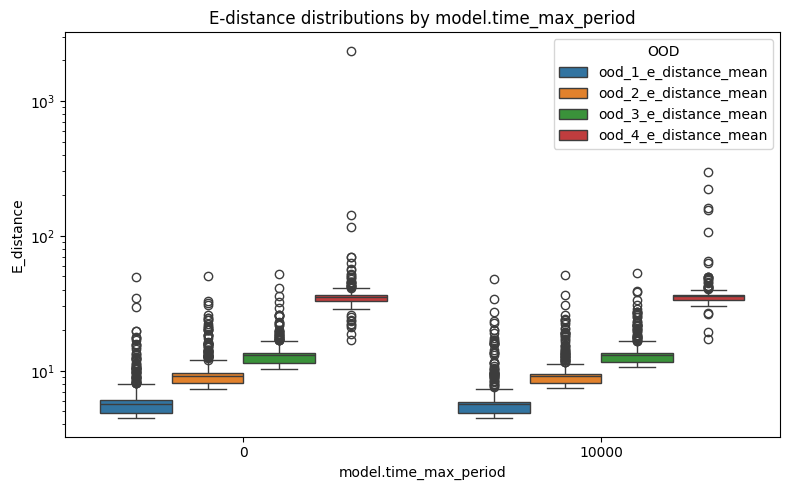

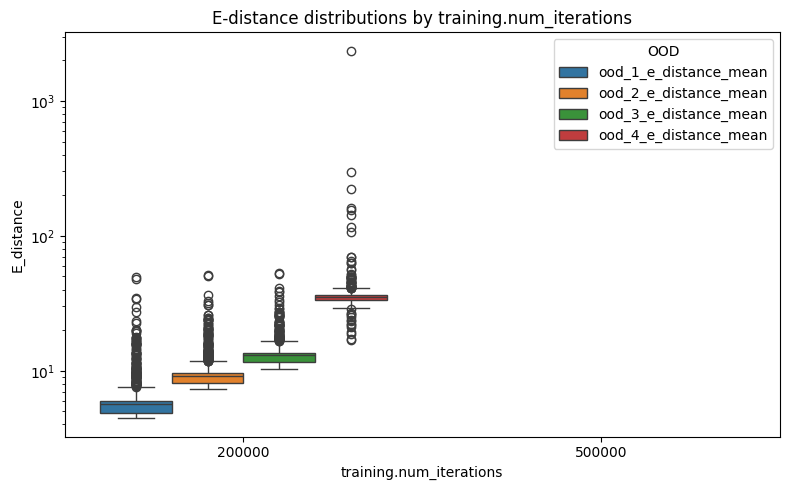

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["ood_1_e_distance_mean", "ood_2_e_distance_mean", 
        "ood_3_e_distance_mean", "ood_4_e_distance_mean"]

for var in vars:
    # Melt into long format
    df_long = df.melt(
        id_vars=var,
        value_vars=cols,
        var_name="OOD",
        value_name="E_distance"
    )
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_long, x=var, y="E_distance", hue="OOD")
    plt.title(f"E-distance distributions by {var}")
    plt.legend(title="OOD")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()


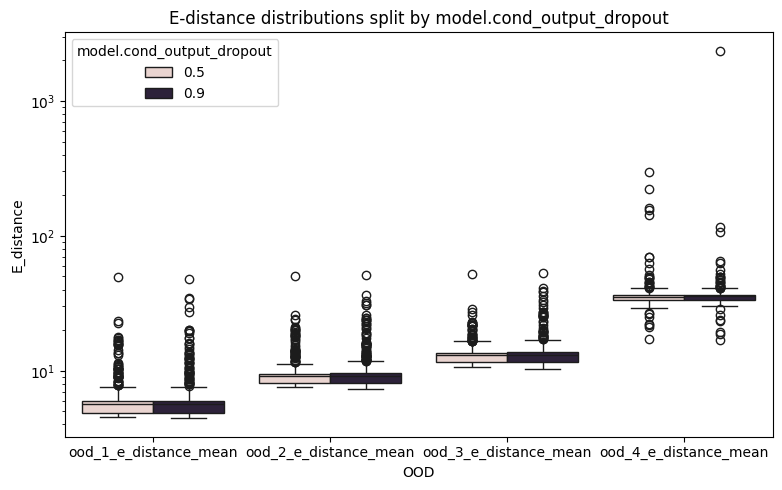

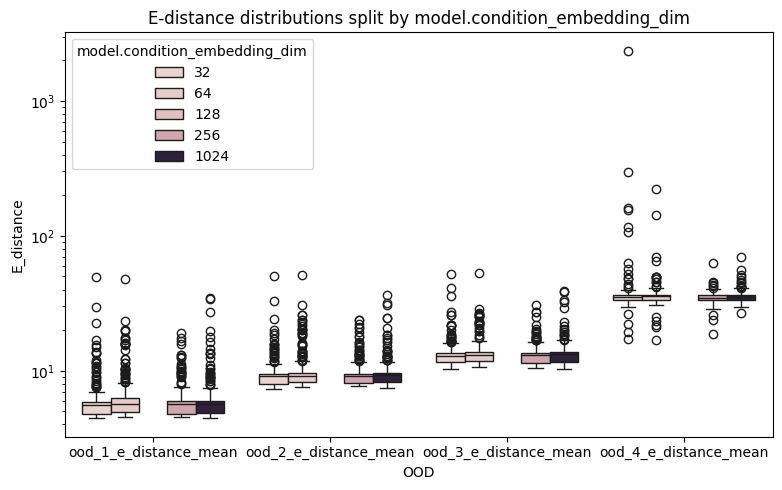

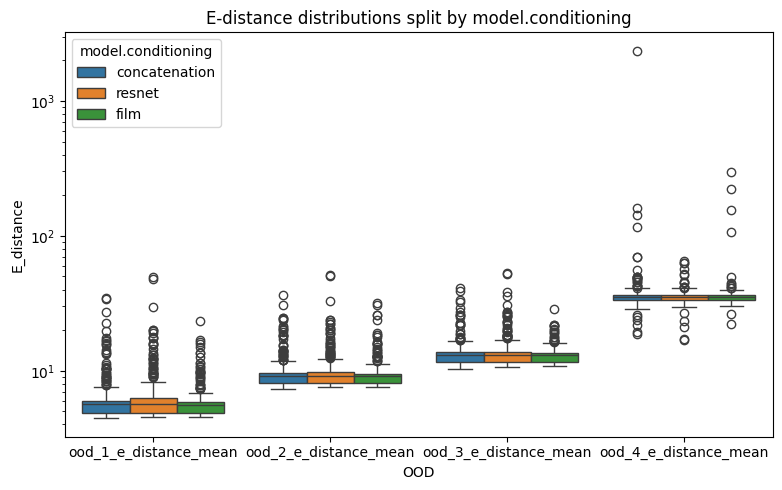

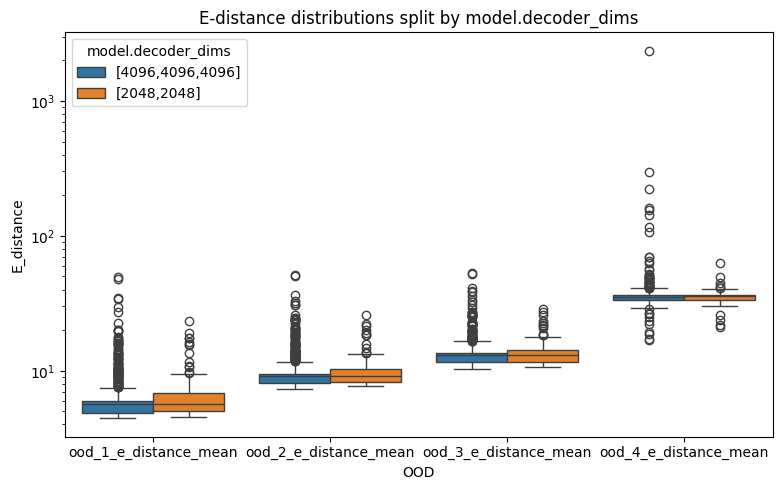

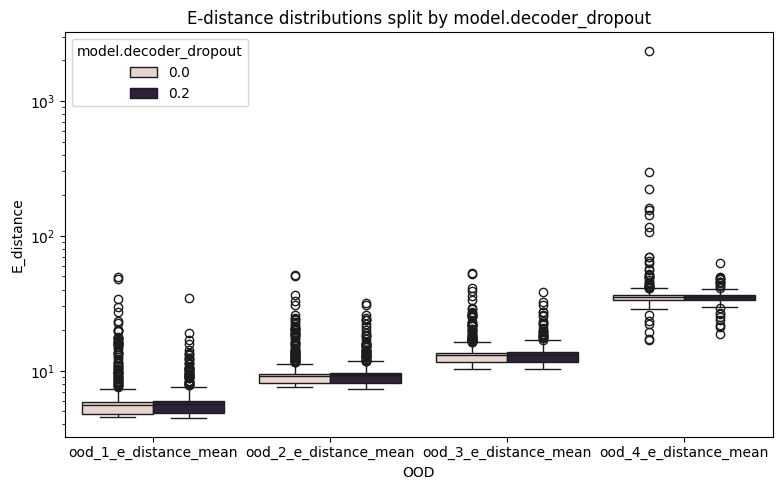

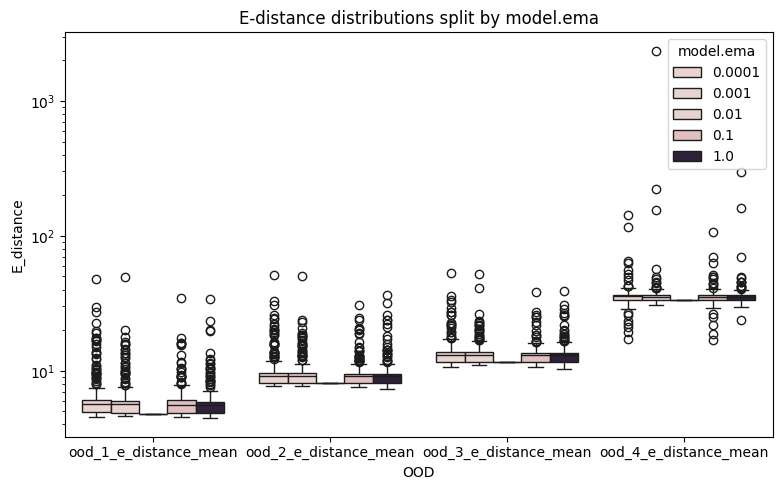

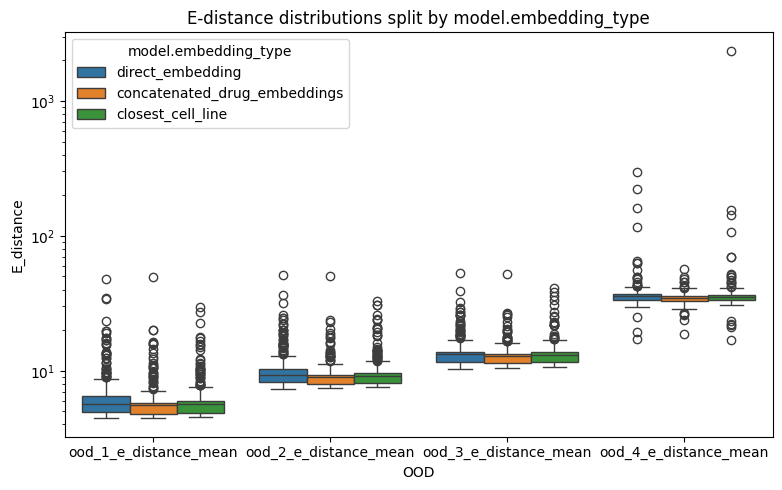

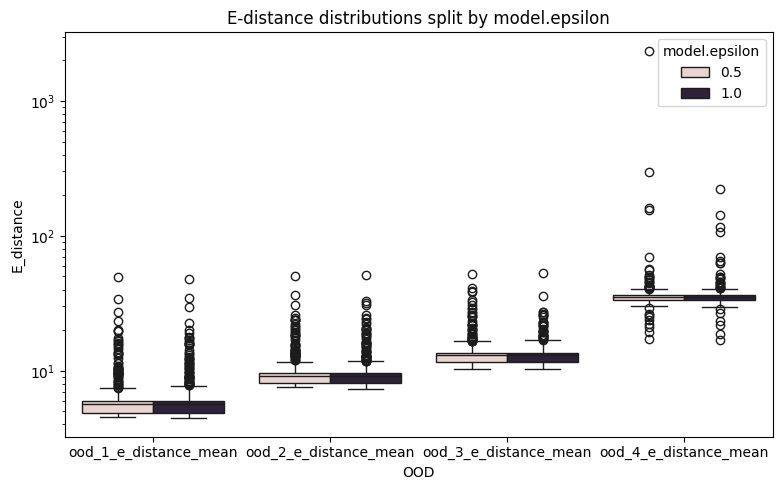

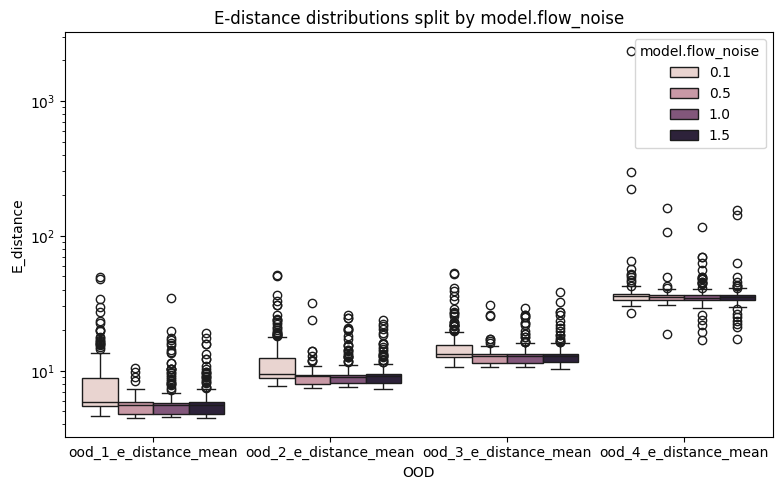

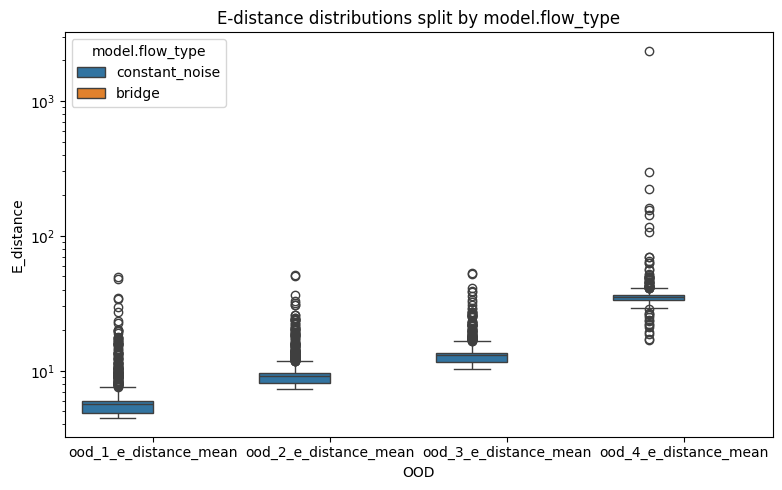

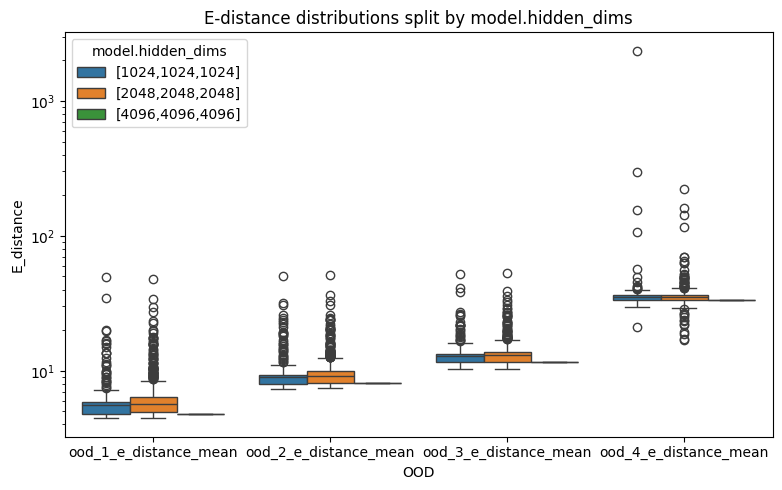

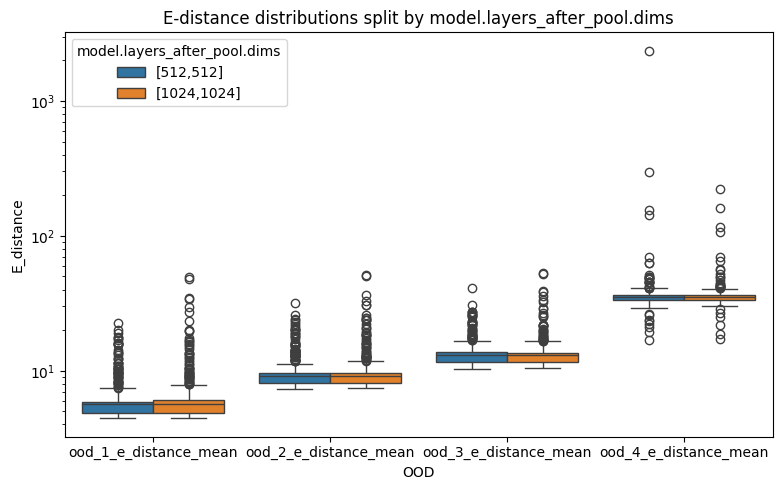

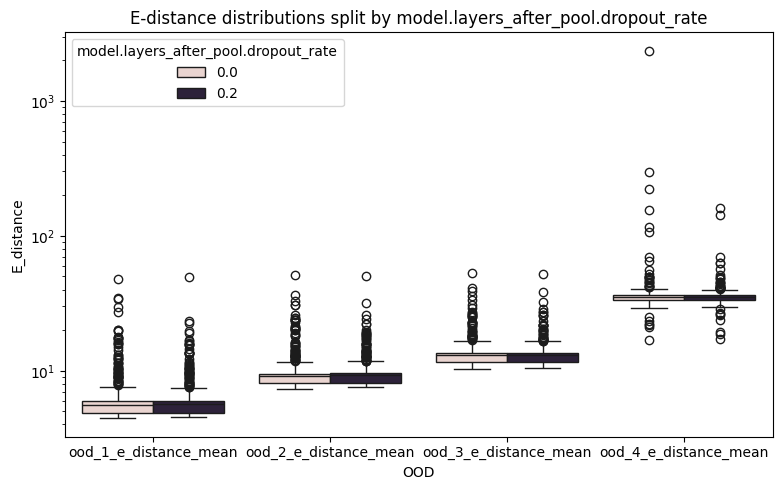

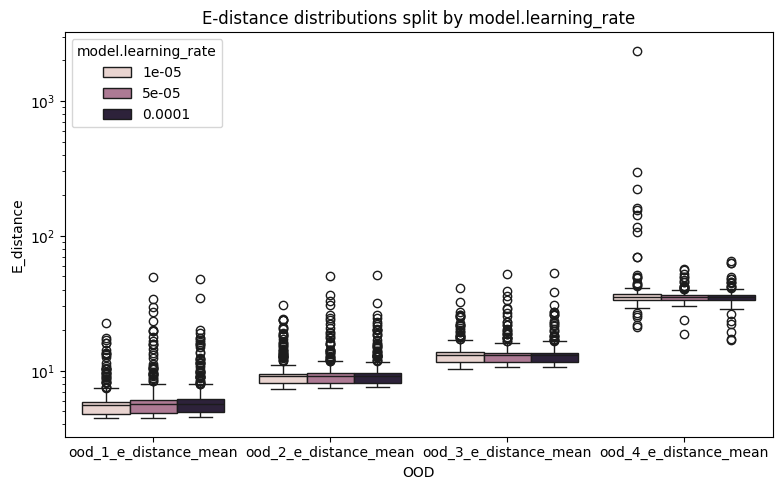

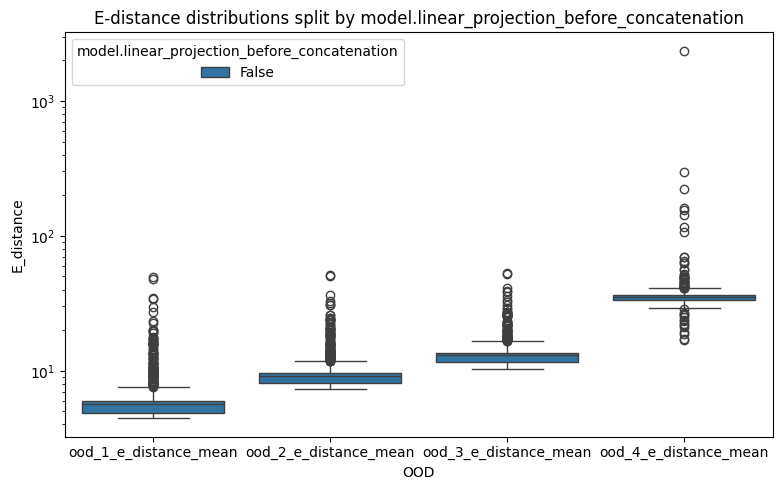

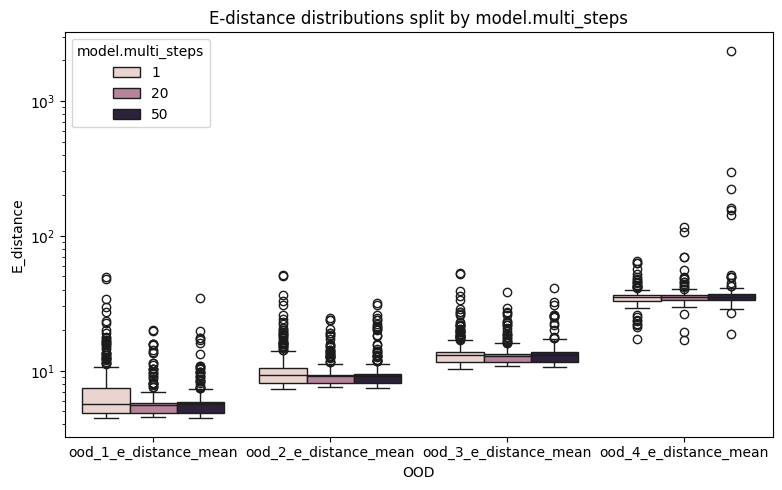

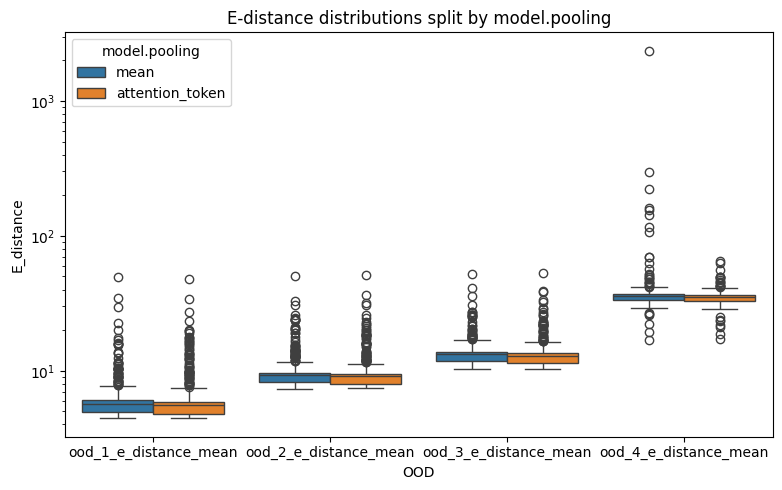

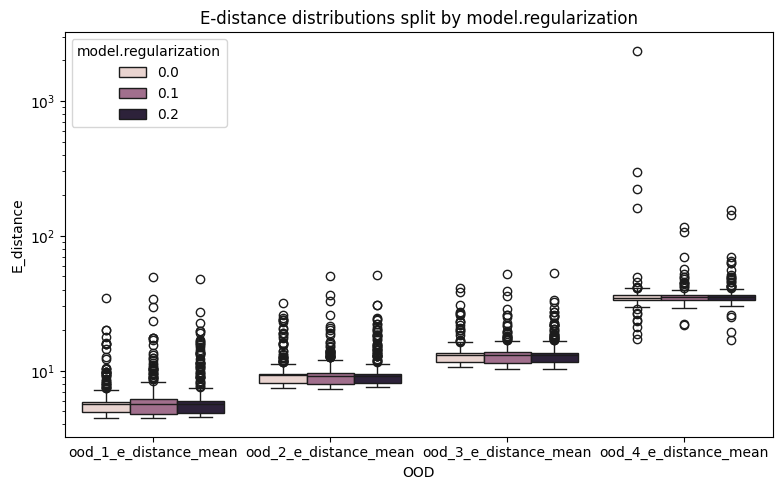

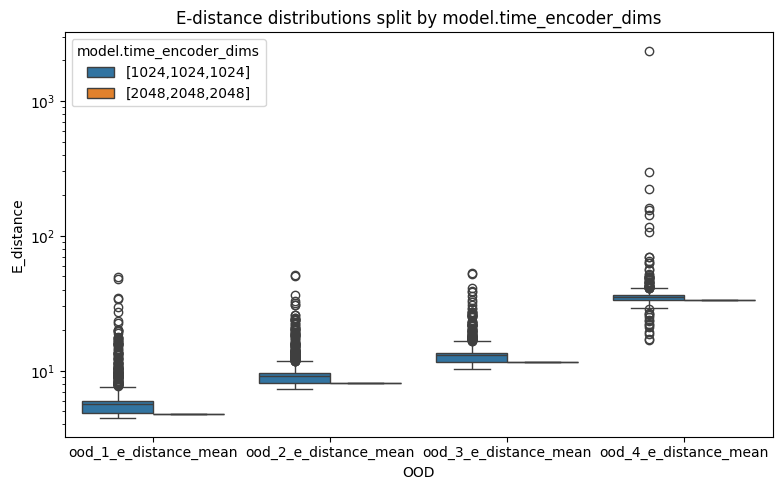

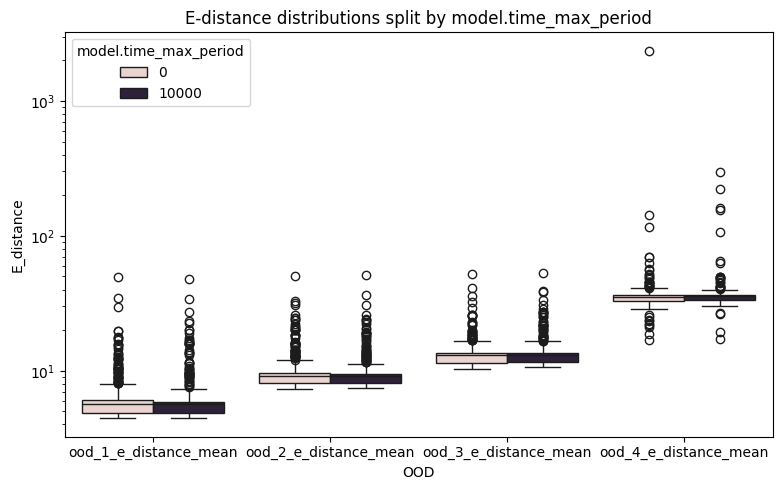

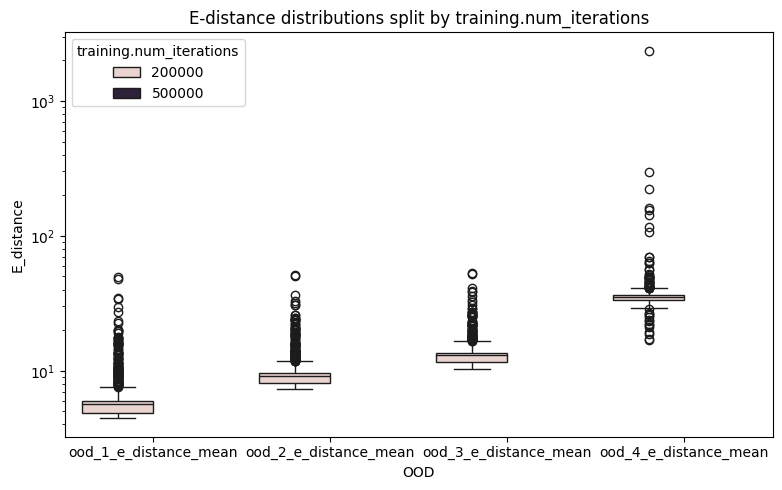

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["ood_1_e_distance_mean", "ood_2_e_distance_mean", 
        "ood_3_e_distance_mean", "ood_4_e_distance_mean"]

for var in vars:
    # Melt into long format for the OOD metrics
    df_long = df.melt(
        id_vars=var,
        value_vars=cols,
        var_name="OOD",
        value_name="E_distance"
    )

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_long,
        x="OOD",                # one box group per OOD metric
        y="E_distance", 
        hue=var,                # separate boxes by var categories, side by side
        dodge=True
    )
    plt.yscale("log")
    plt.title(f"E-distance distributions split by {var}")
    plt.legend(title=var)
    plt.tight_layout()
    plt.show()


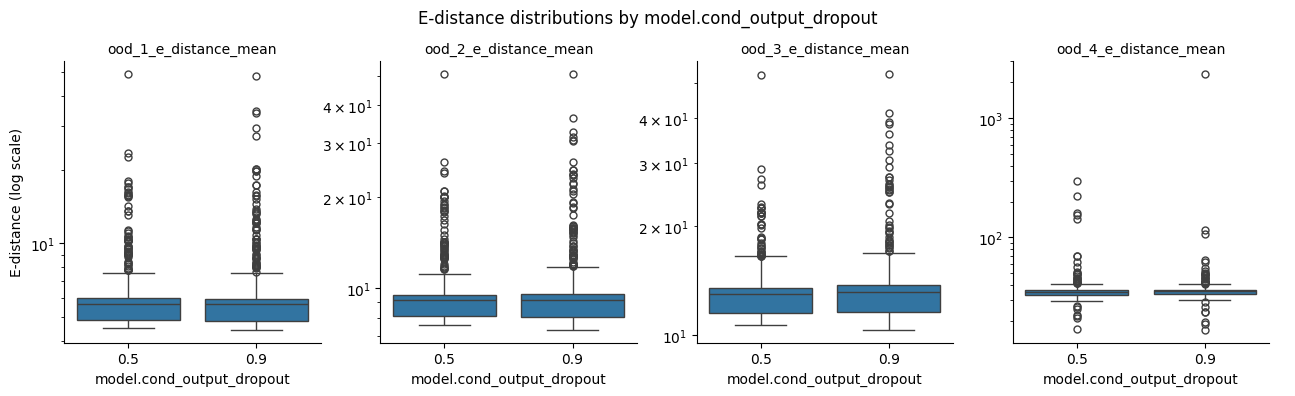

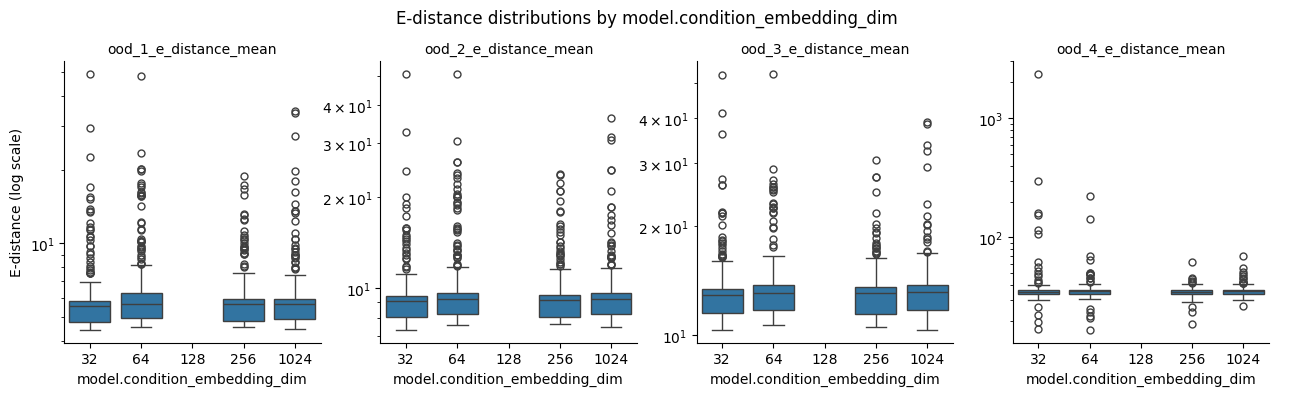

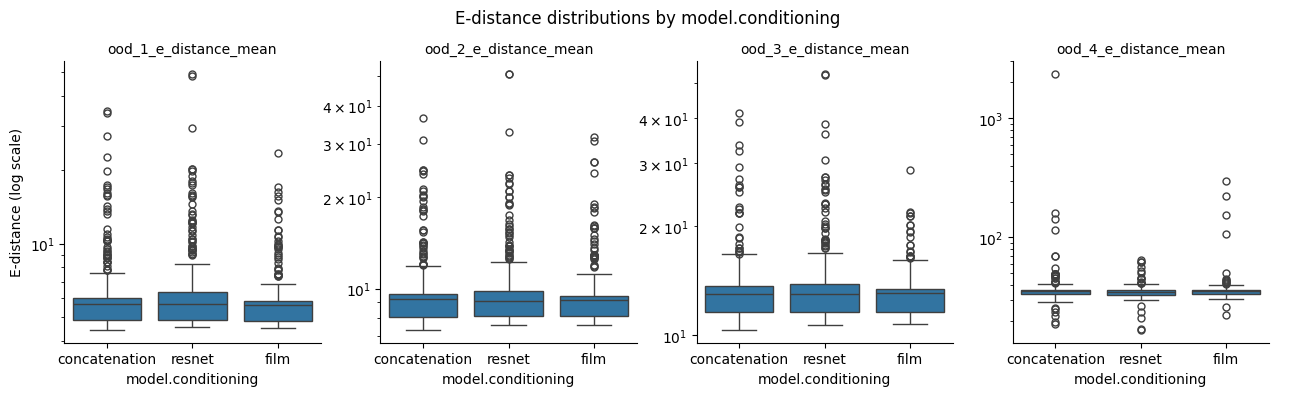

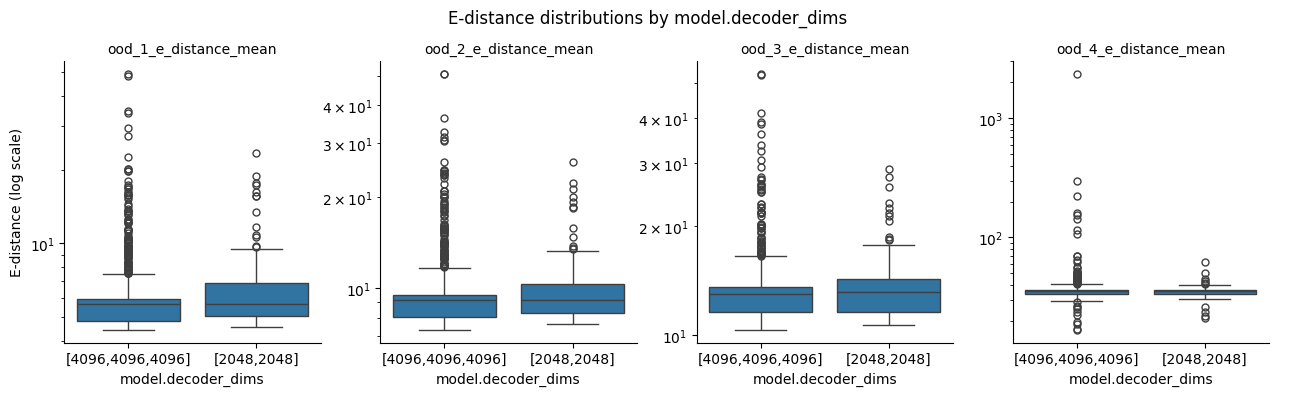

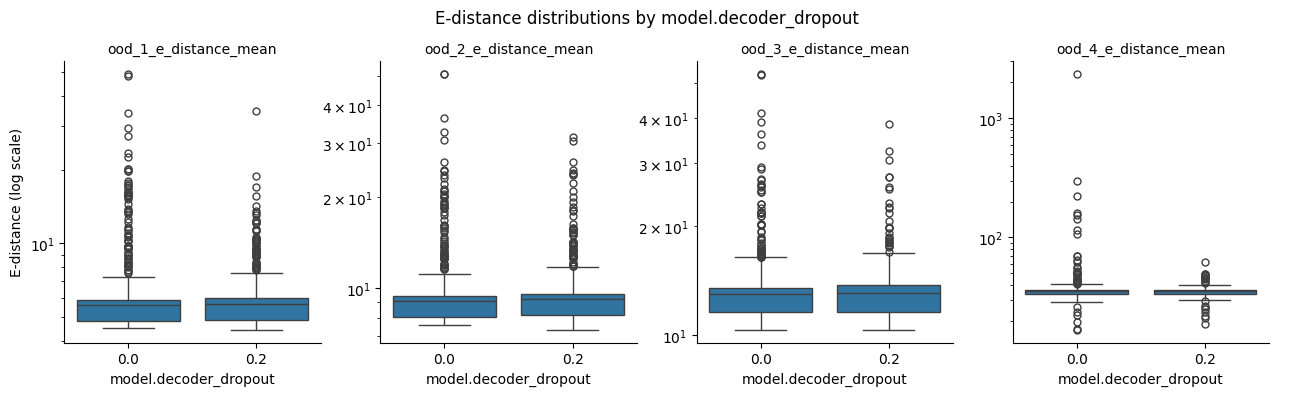

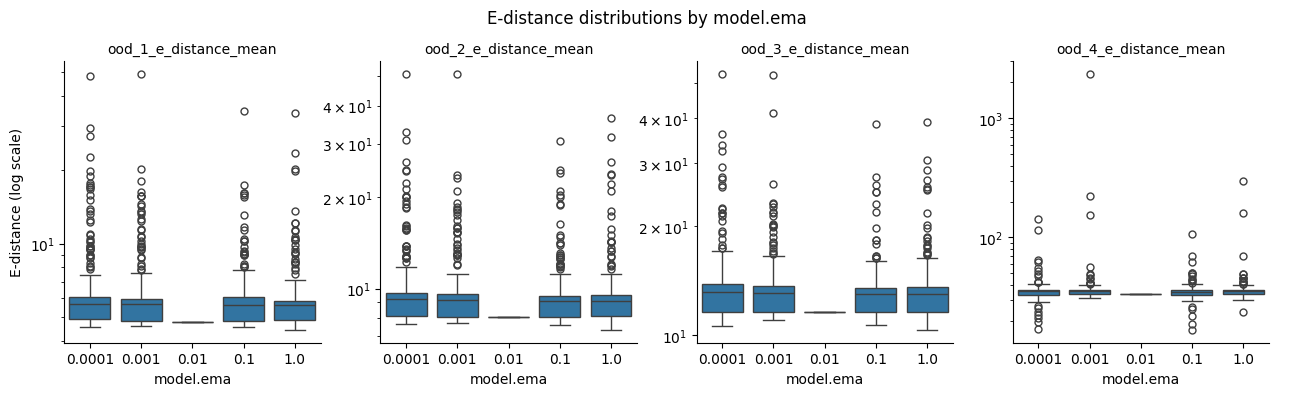

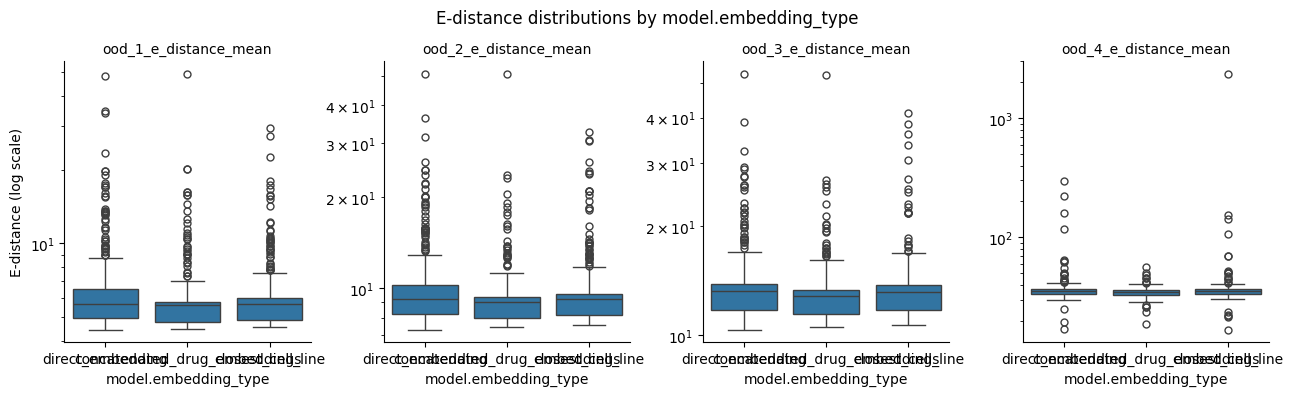

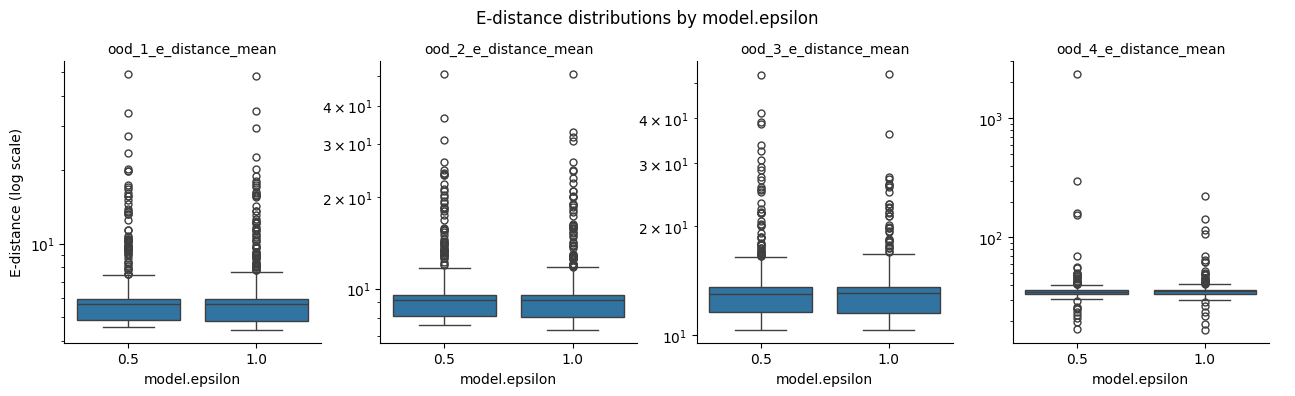

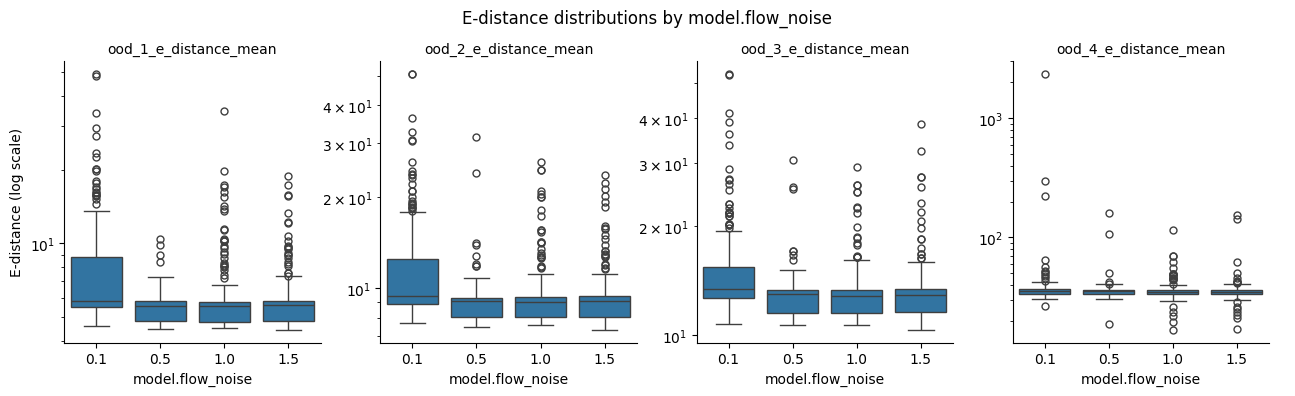

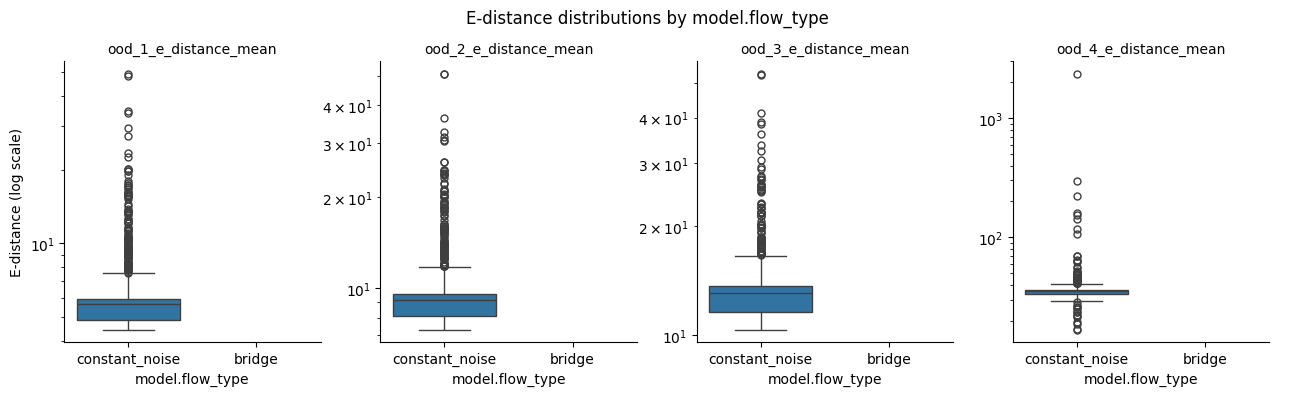

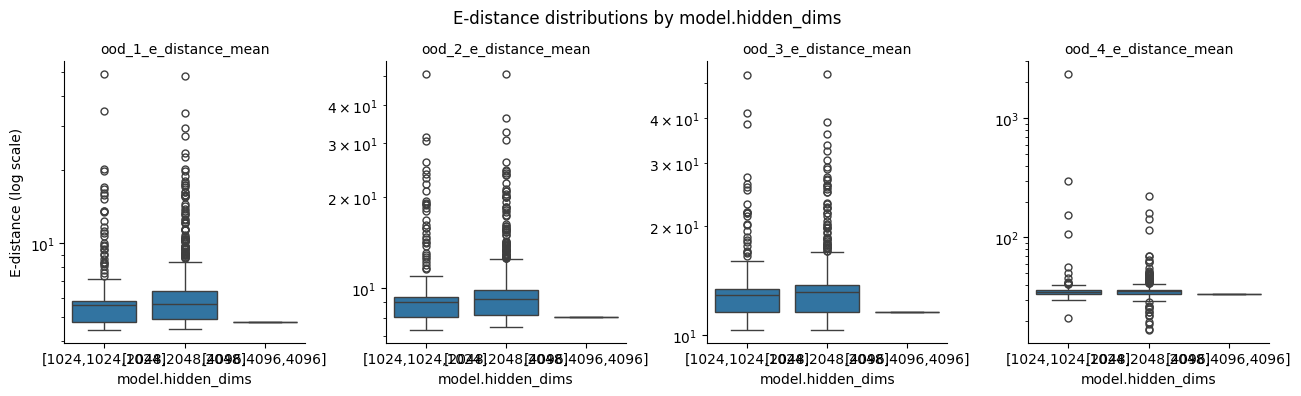

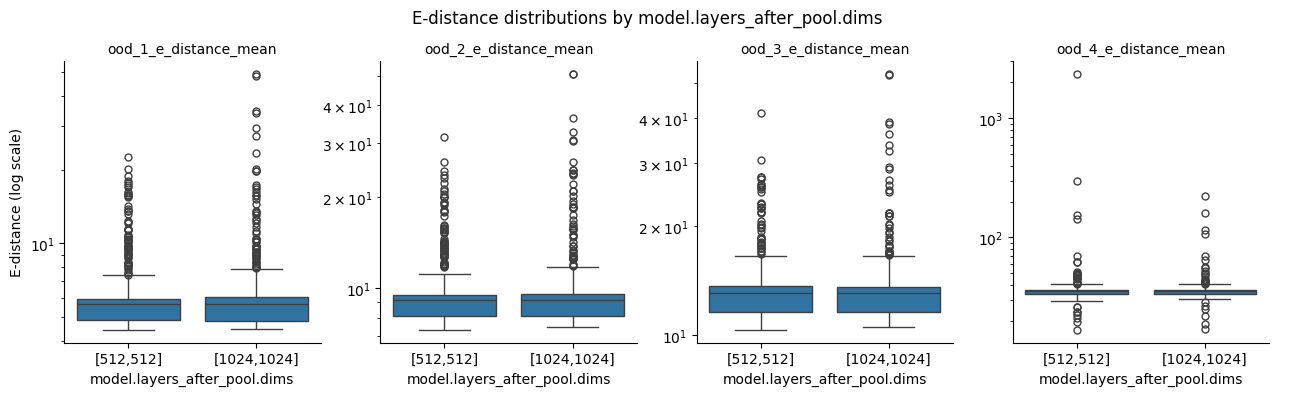

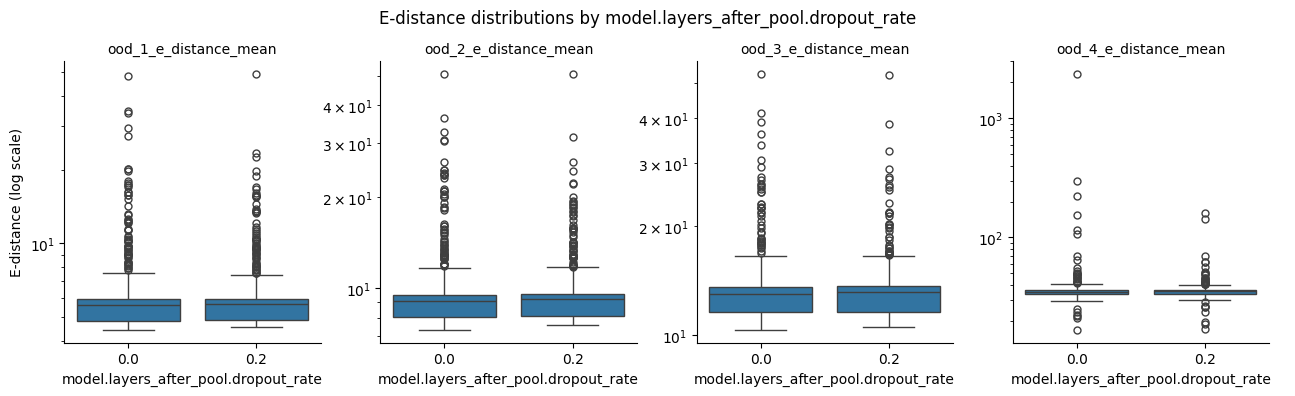

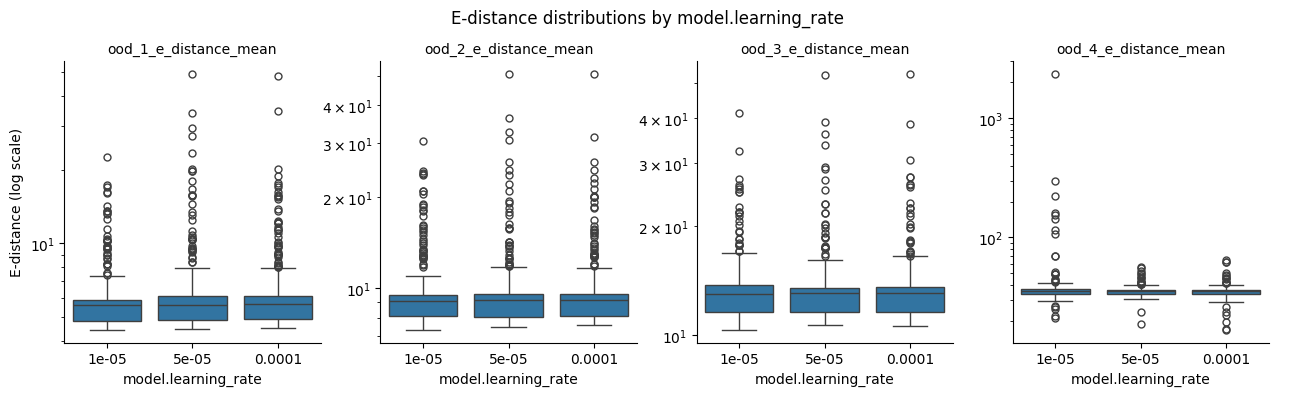

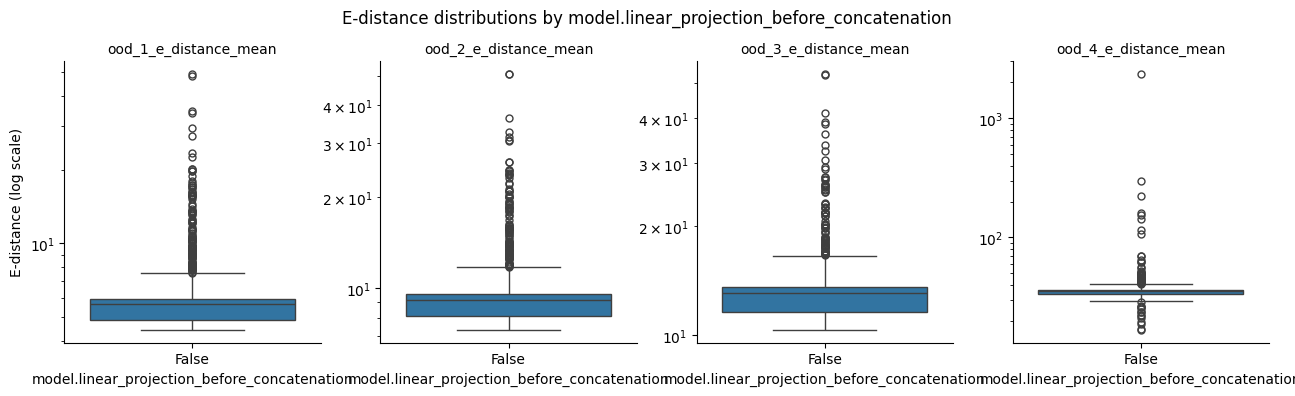

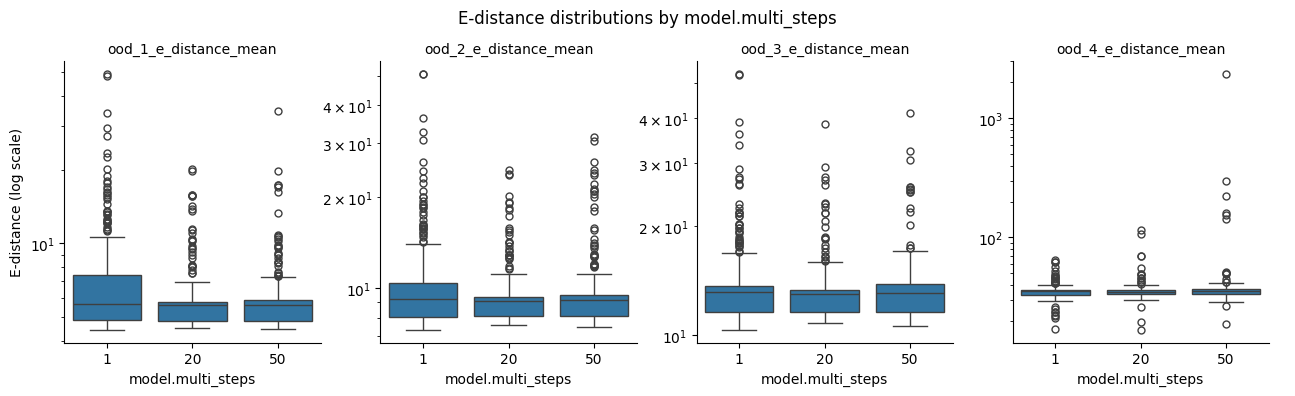

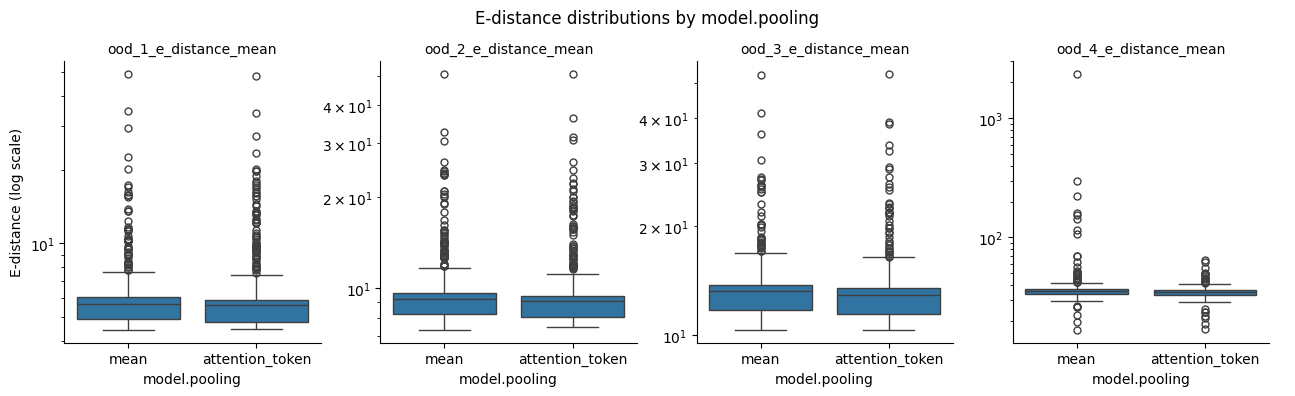

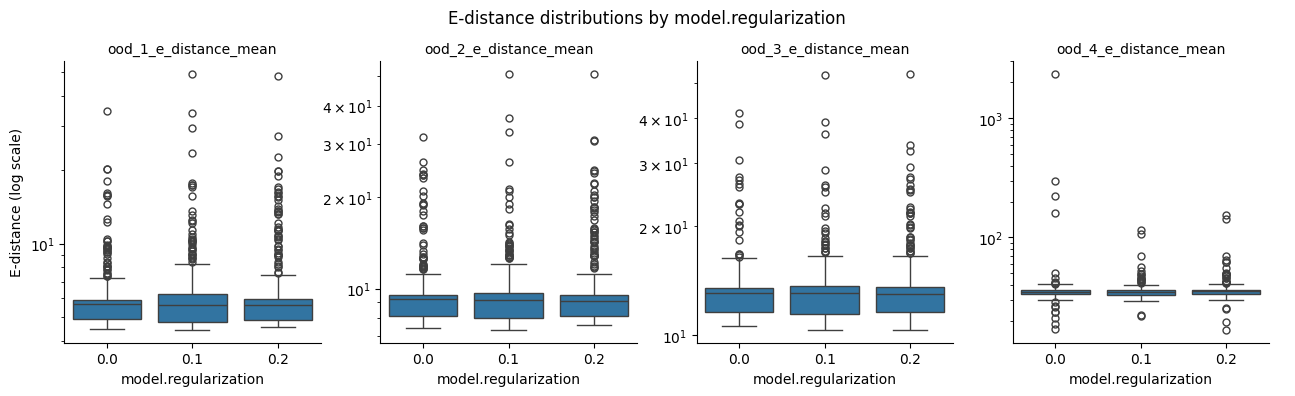

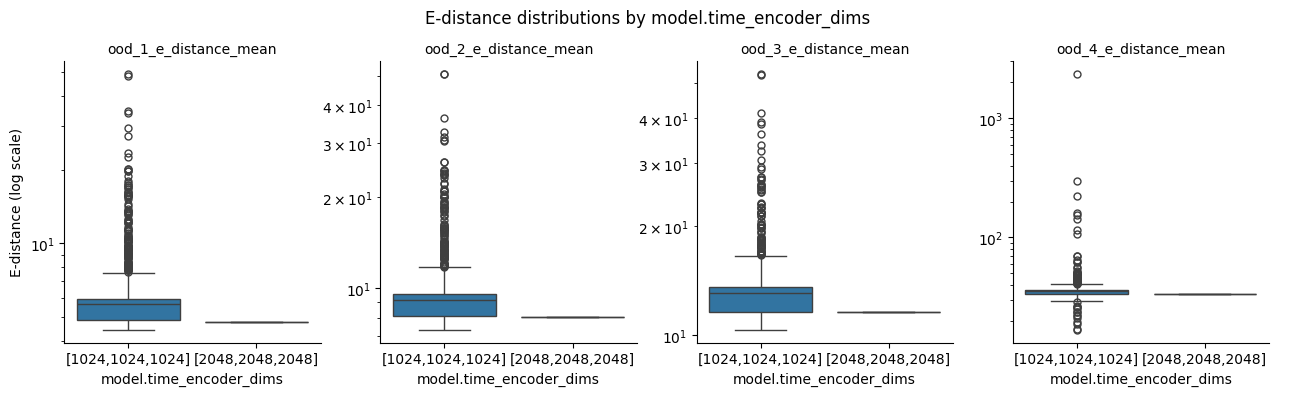

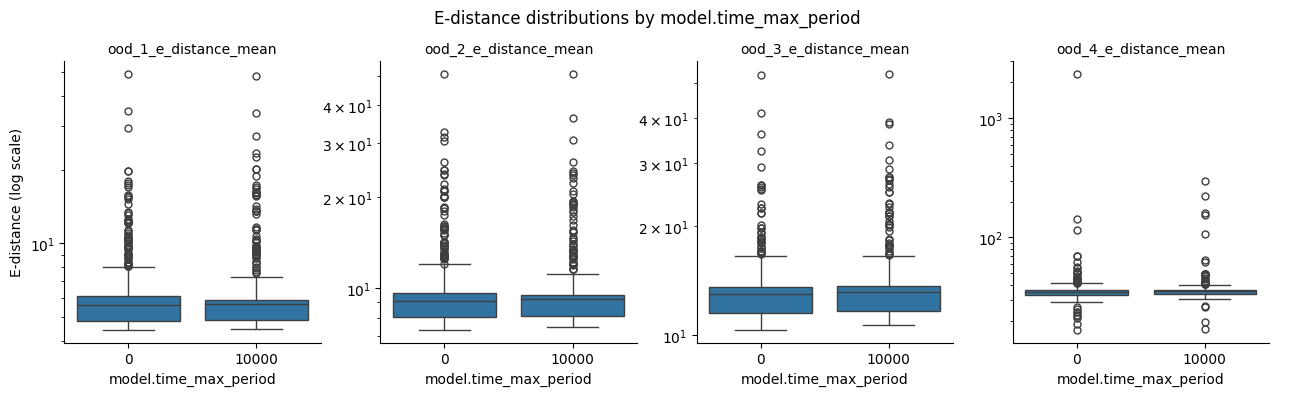

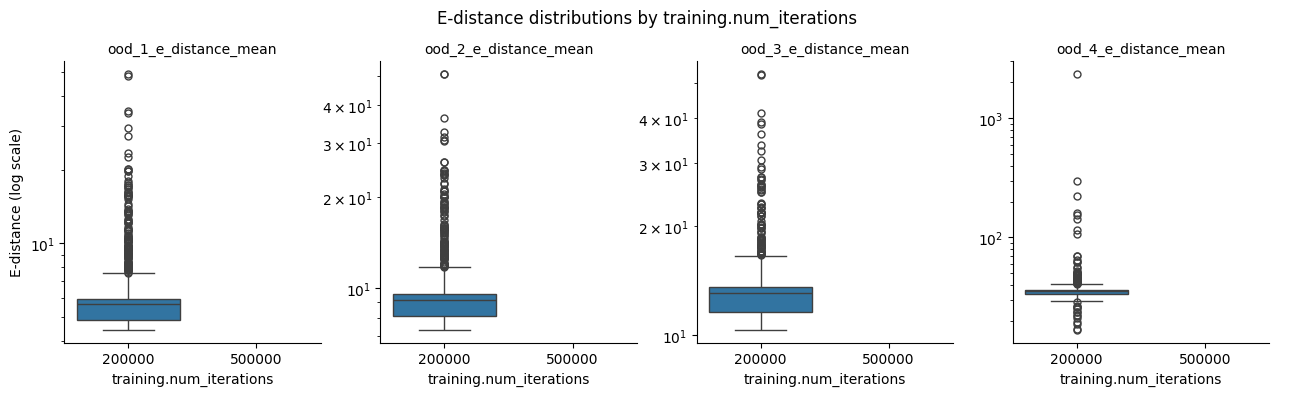

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["ood_1_e_distance_mean", "ood_2_e_distance_mean", 
        "ood_3_e_distance_mean", "ood_4_e_distance_mean"]

for var in vars:
    df_long = df.melt(
        id_vars=var,
        value_vars=cols,
        var_name="OOD",
        value_name="E_distance"
    )
    
    g = sns.catplot(
        data=df_long,
        x=var,
        y="E_distance",
        col="OOD",
        kind="box",
        sharey=False,       # independent y-scale per facet
        height=4,
        aspect=0.8
    )
    
    g.set(yscale="log")    # <- set log scale for all y-axes
    g.set_titles("{col_name}")
    g.set_axis_labels(var, "E-distance (log scale)")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"E-distance distributions by {var}")
    plt.show()


/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


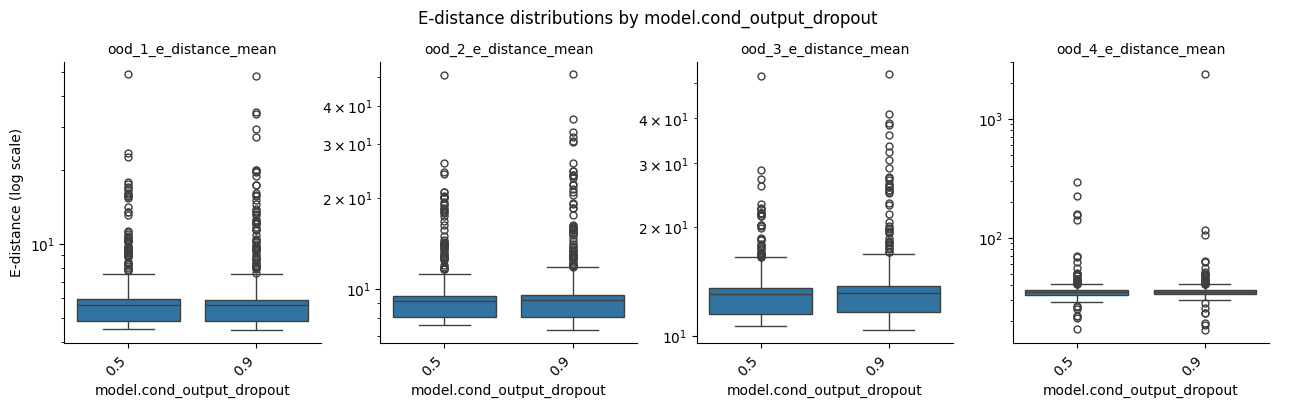

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


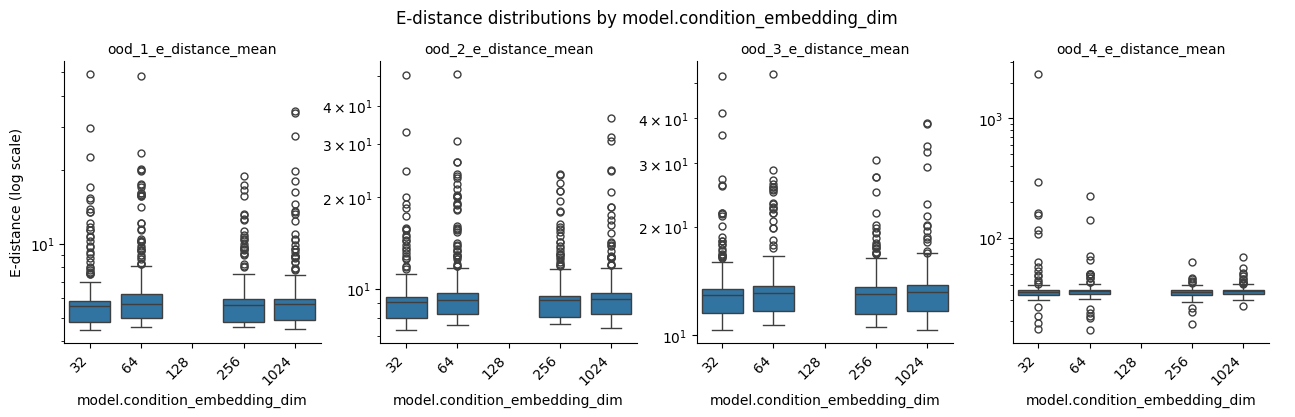

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


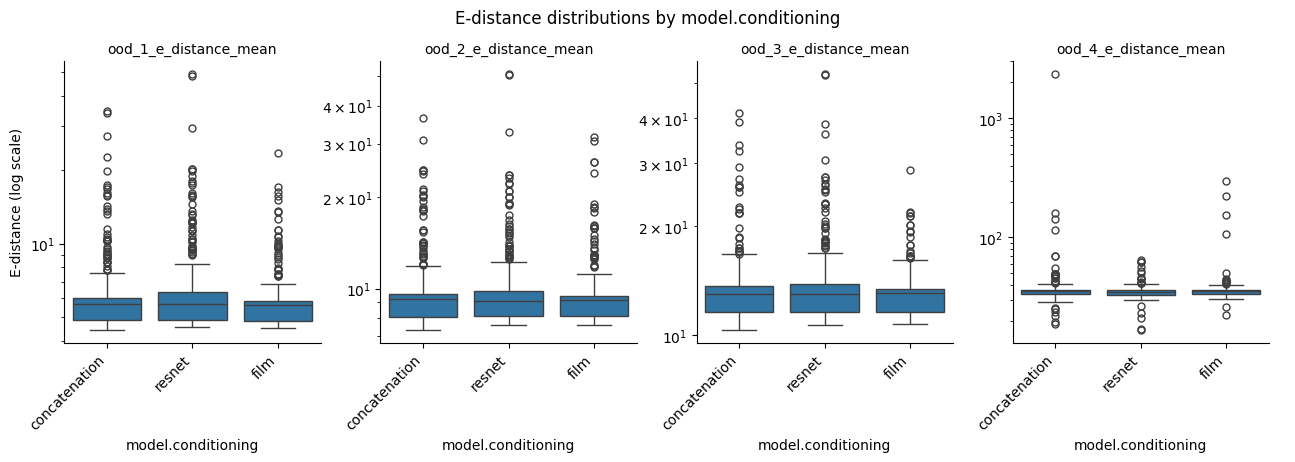

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


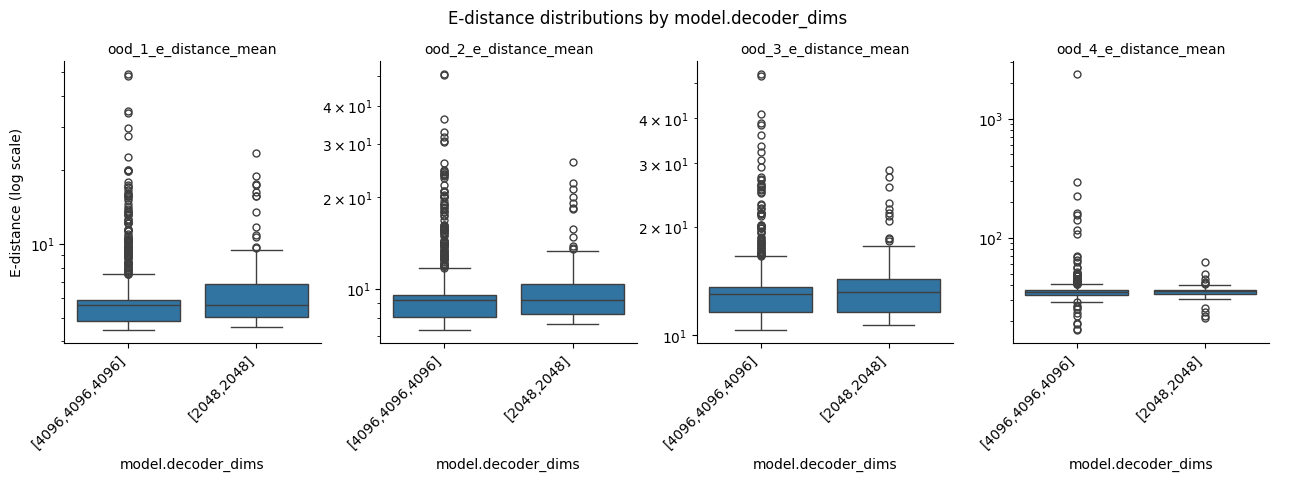

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


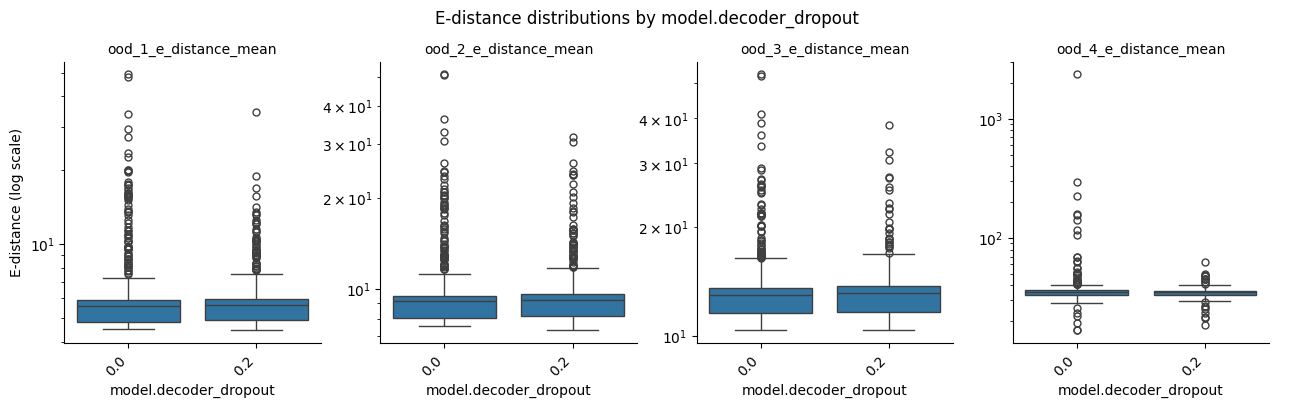

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


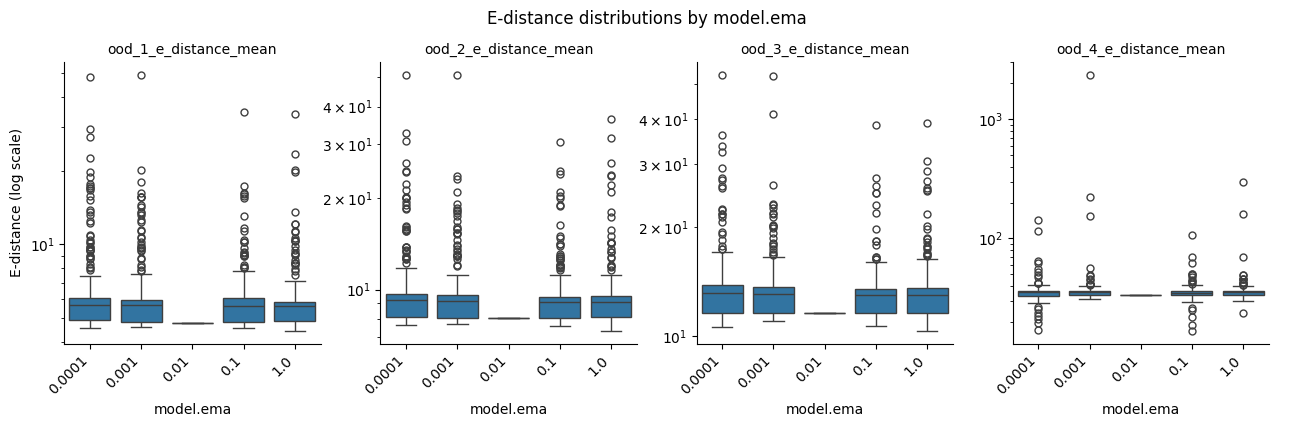

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


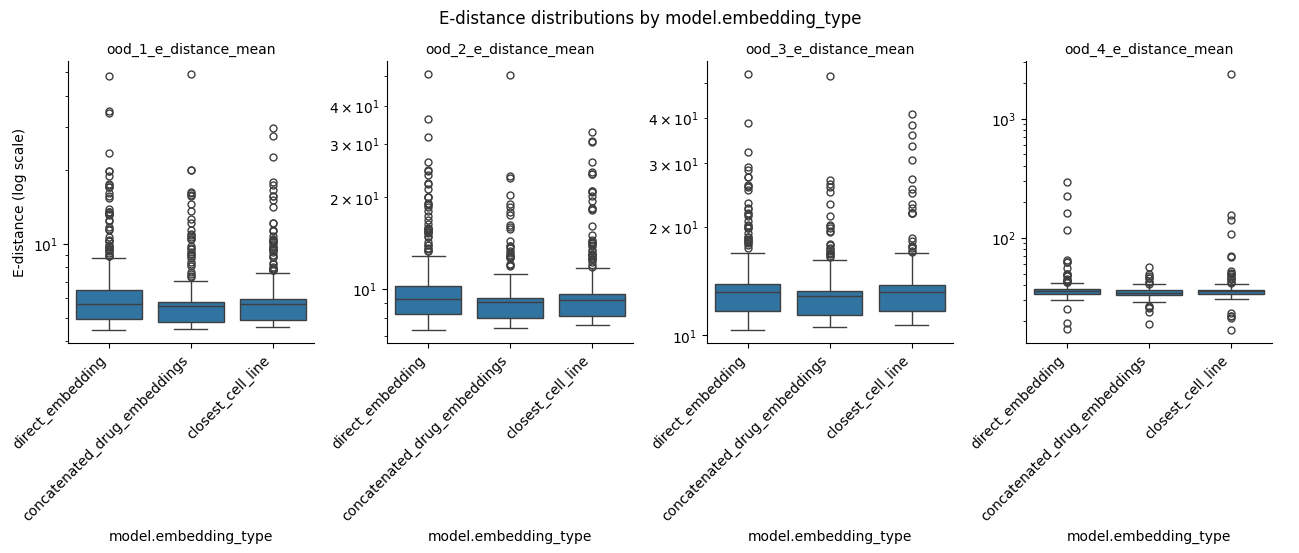

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


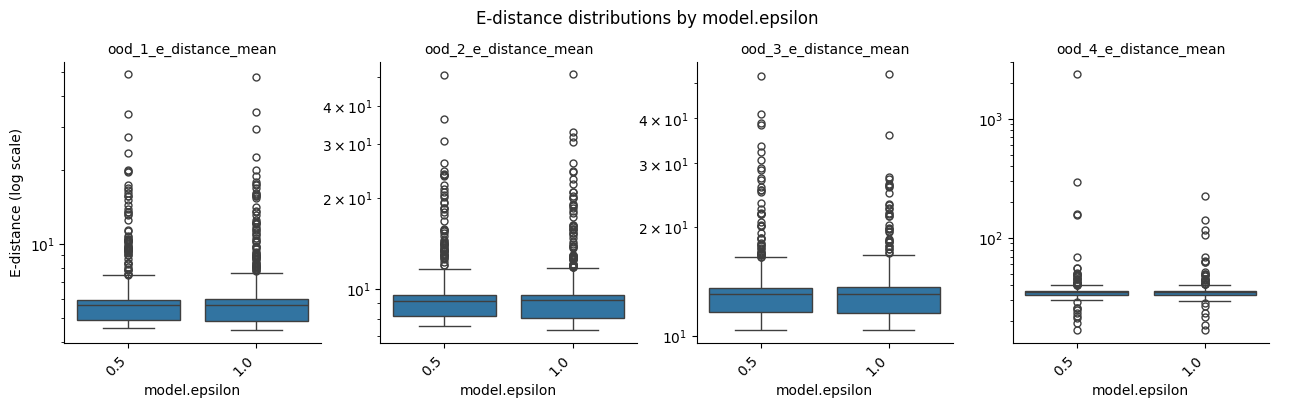

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


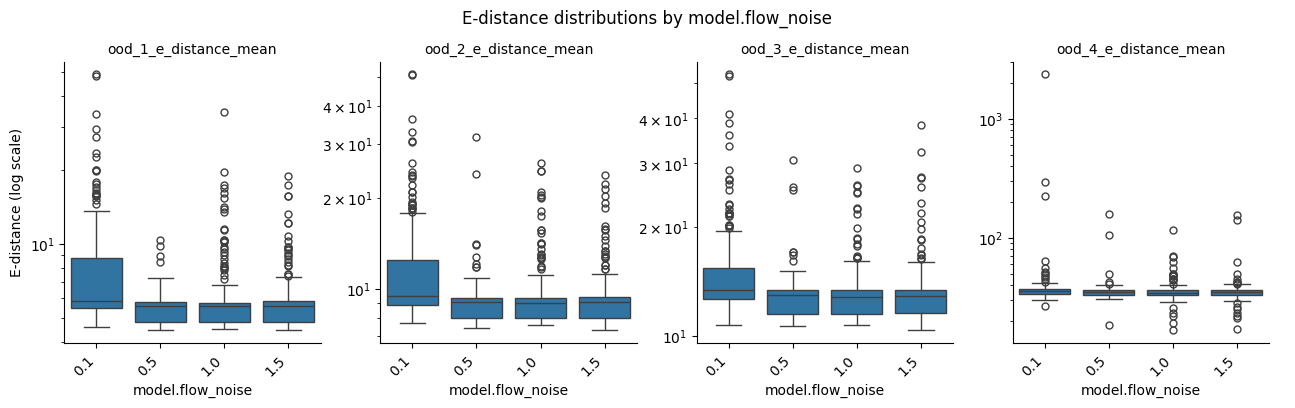

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


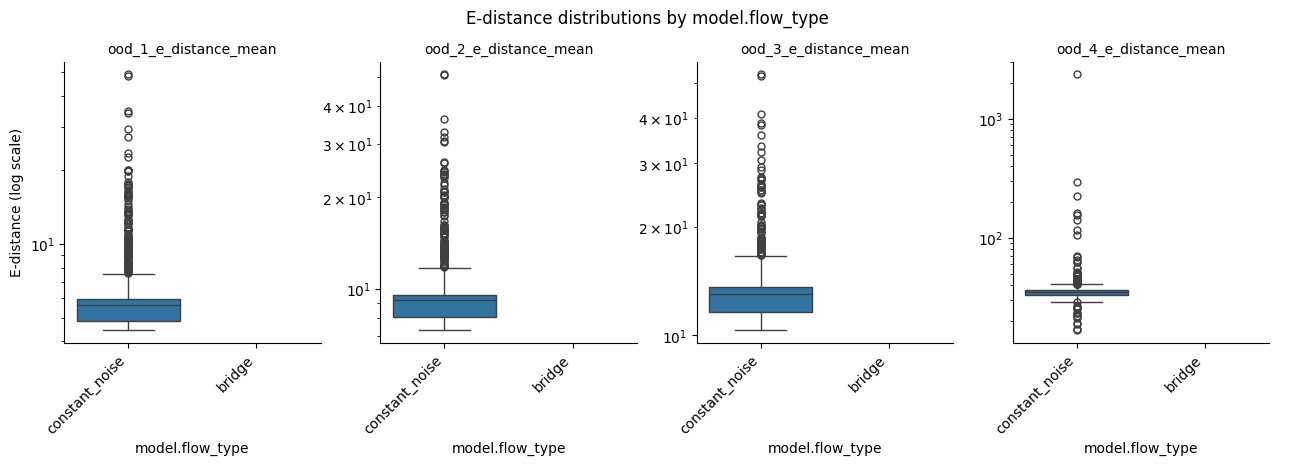

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


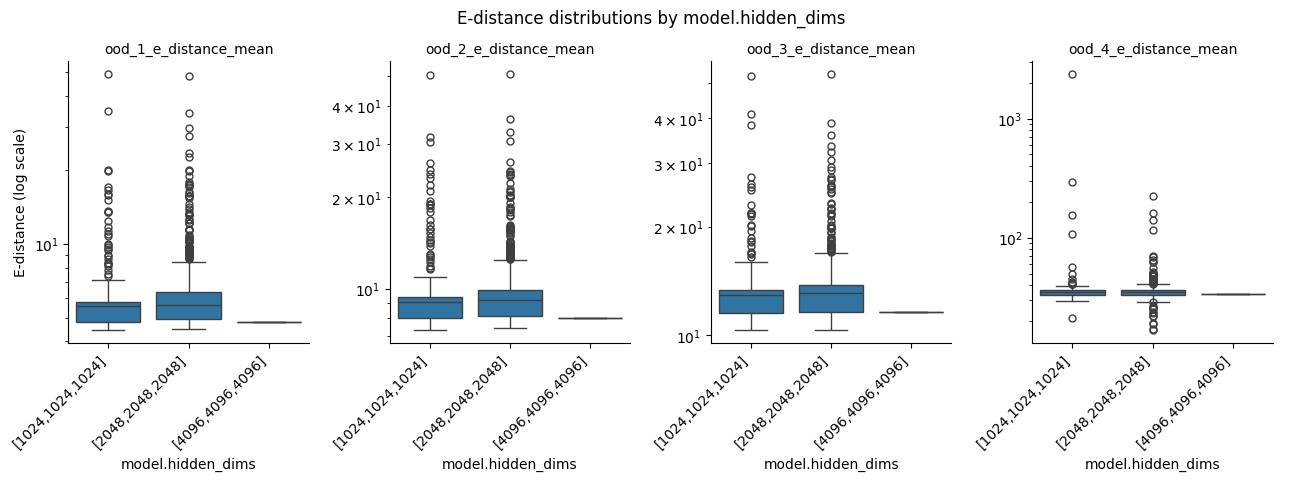

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


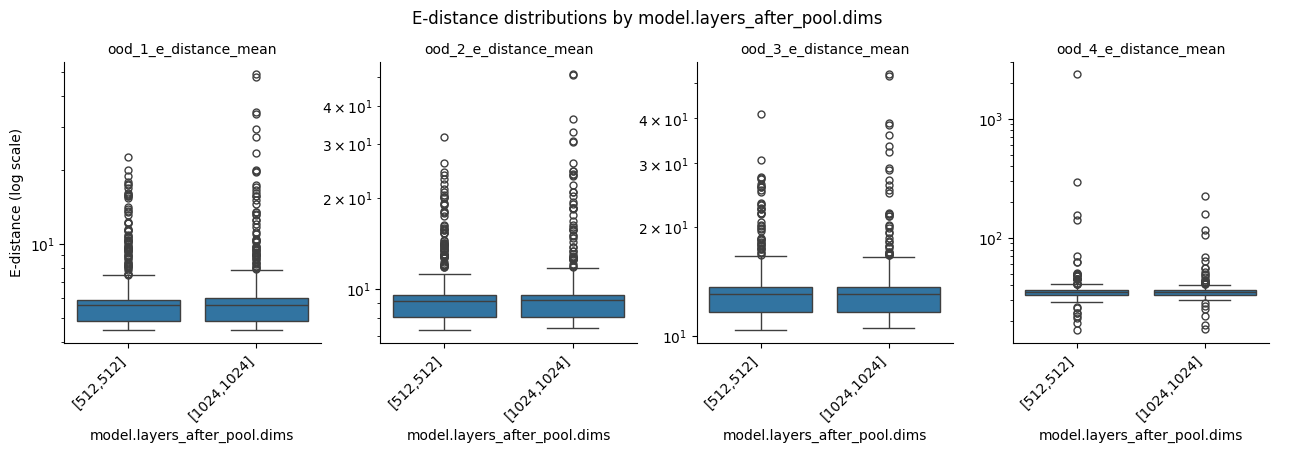

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


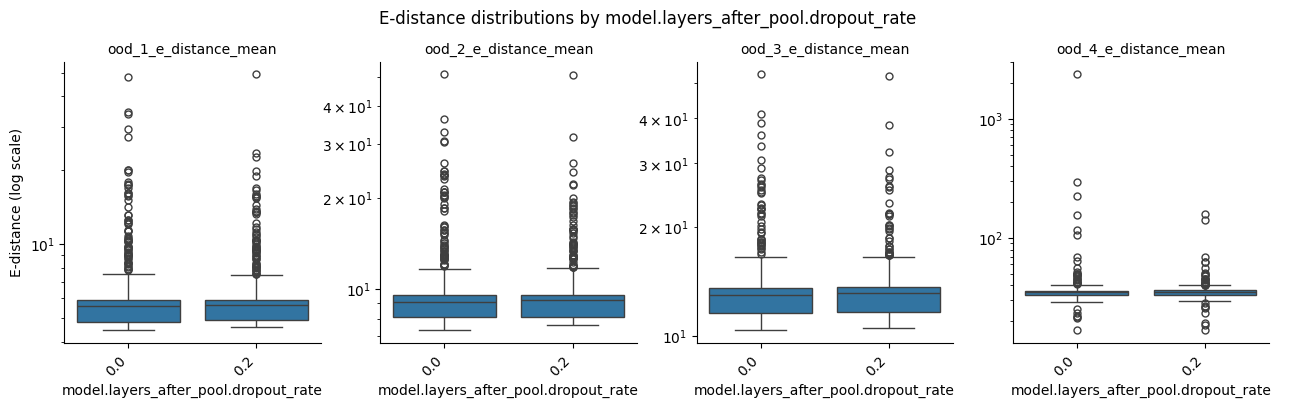

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


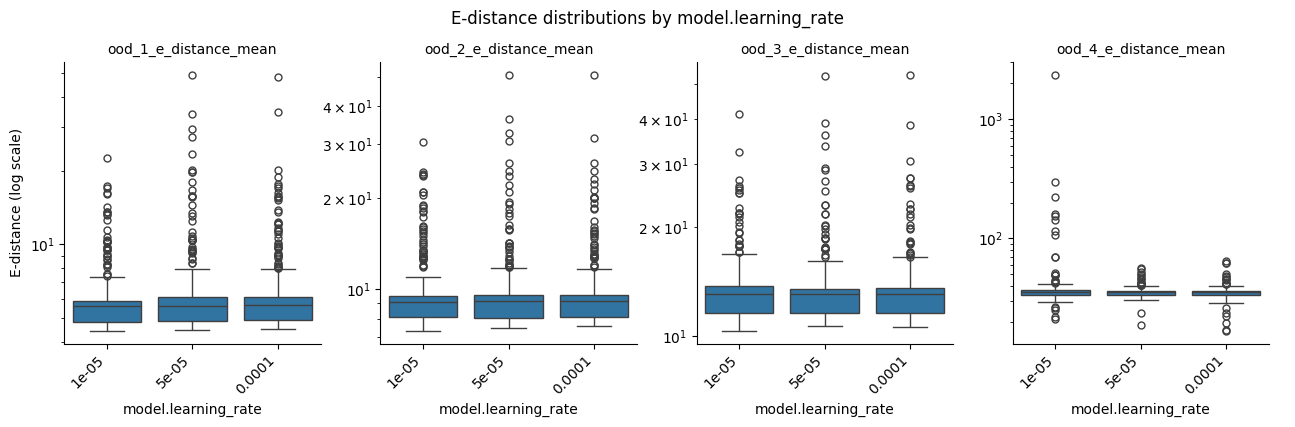

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


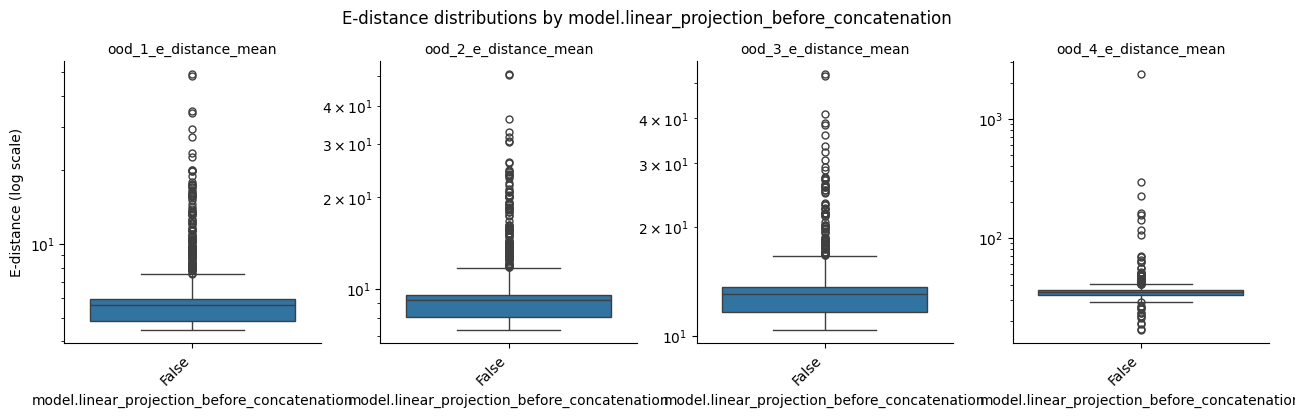

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


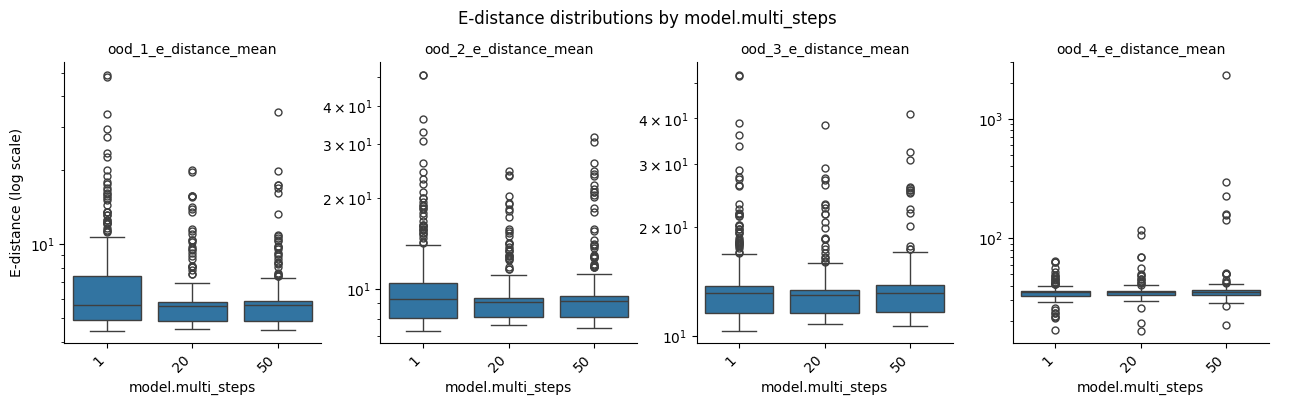

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


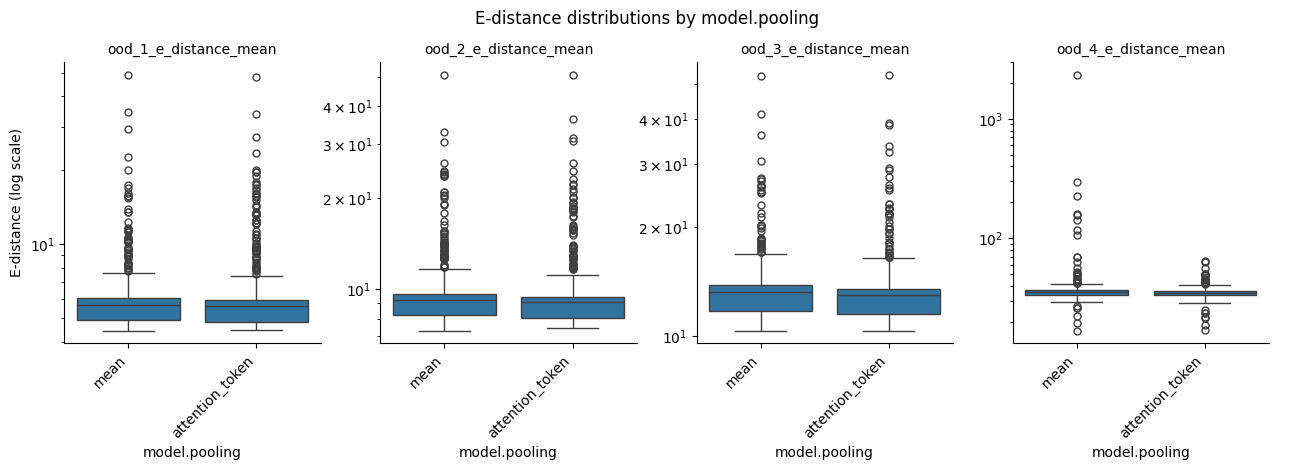

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


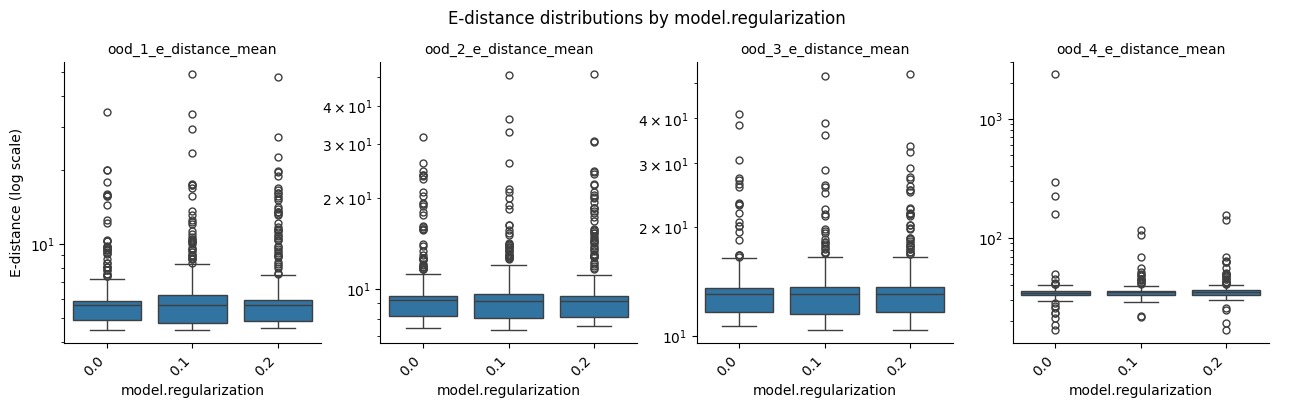

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


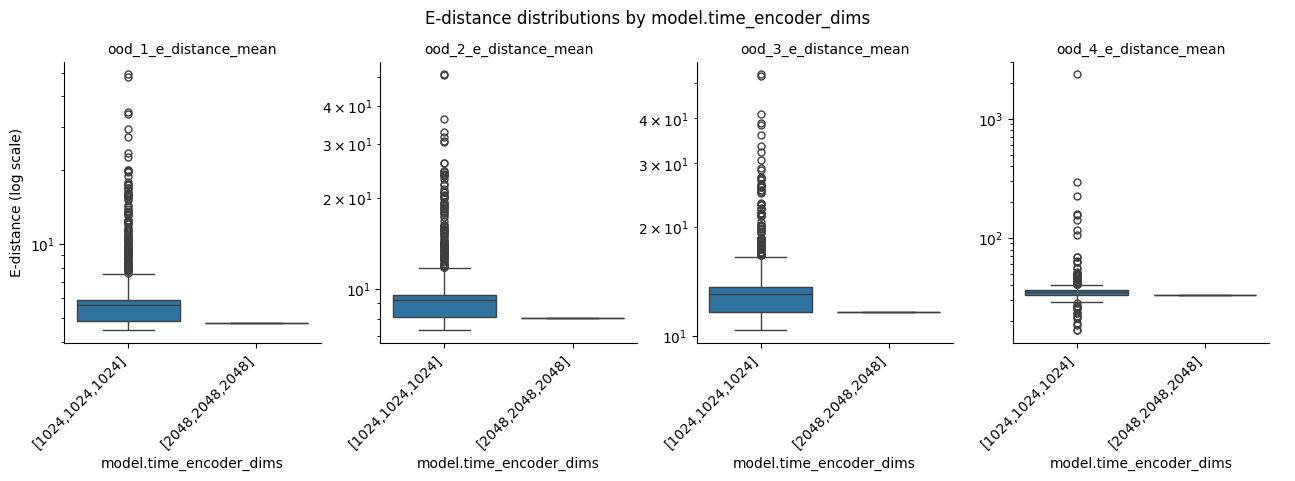

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


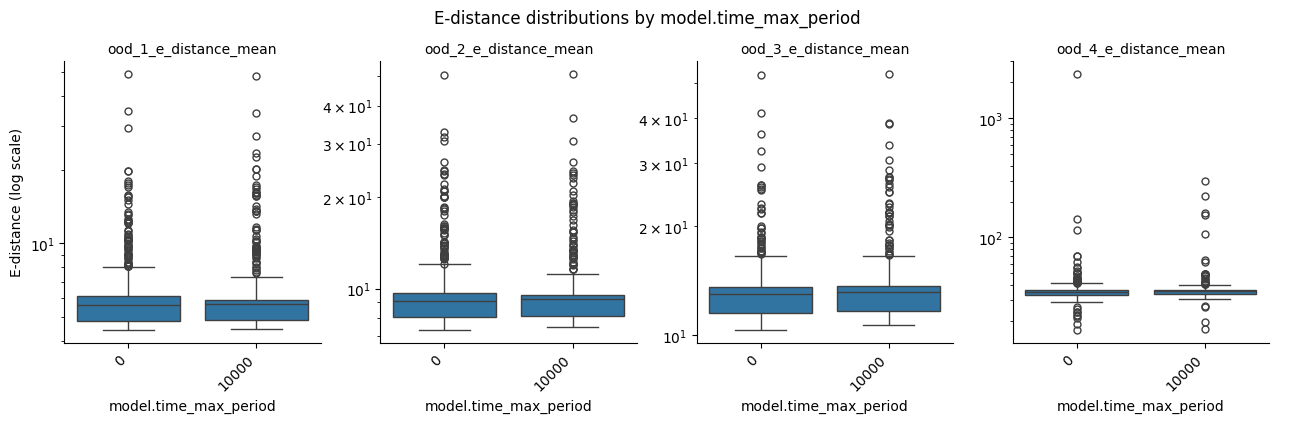

/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1545880/180375640.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


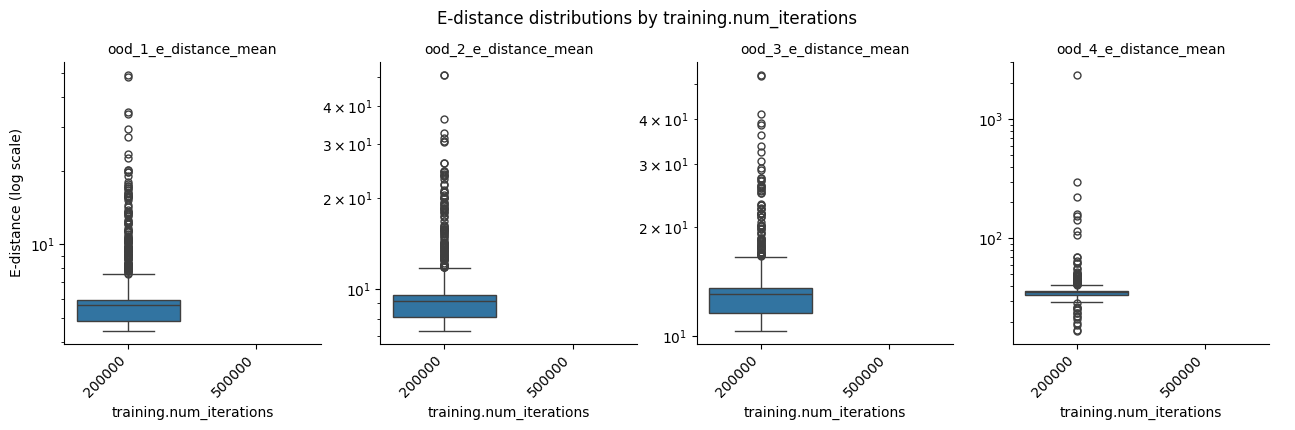

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["ood_1_e_distance_mean", "ood_2_e_distance_mean", 
        "ood_3_e_distance_mean", "ood_4_e_distance_mean"]

for var in vars:
    df_long = df.melt(
        id_vars=var,
        value_vars=cols,
        var_name="OOD",
        value_name="E_distance"
    )
    
    g = sns.catplot(
        data=df_long,
        x=var,
        y="E_distance",
        col="OOD",
        kind="box",
        sharey=False,       # independent y-scale per facet
        height=4,
        aspect=0.8
    )
    
    g.set(yscale="log")
    g.set_titles("{col_name}")
    g.set_axis_labels(var, "E-distance (log scale)")
    
    # Rotate x-axis labels for all facets
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"E-distance distributions by {var}")
    plt.show()


In [19]:
filter_vars = {"model.condition_embedding_dim": 32,
"model.decoder_dims": "[4096,4096,4096]",
"model.embedding_type": "concatenated_drug_embeddings",
"model.hidden_dims": "[1024,1024,1024]",
"model.multi_steps": 20}

In [20]:
df2 = df.copy()
for k,v in filter_vars.items():
    df2 = df2[df2[k]==v]

In [21]:
df2

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,dataset.dataset_path,dataset.perturbation_covariate_reps.drug,...,pca_decoded_ood_1_r_squared_mean,pca_decoded_ood_2_e_distance_mean,pca_decoded_ood_2_mmd_mean,pca_decoded_ood_2_r_squared_mean,pca_decoded_ood_3_e_distance_mean,pca_decoded_ood_3_mmd_mean,pca_decoded_ood_3_r_squared_mean,pca_decoded_ood_4_e_distance_mean,pca_decoded_ood_4_mmd_mean,pca_decoded_ood_4_r_squared_mean
86,valiant-dust-6318,finished,-,NaN,NaN,2025-09-10T14:29:32.000Z,3337,NaN,NaN,NaN,...,0.922846,7.837567,0.023875,0.874382,11.269510,0.032756,0.841293,33.001842,0.087447,0.589420
126,sage-pond-6236,finished,-,NaN,NaN,2025-09-10T06:09:35.000Z,3573,NaN,NaN,NaN,...,0.922305,7.913641,0.024104,0.873465,11.378542,0.033104,0.840088,33.332245,0.088505,0.585605
329,silvery-pond-4748,finished,-,NaN,NaN,2025-09-06T13:01:12.000Z,3642,NaN,NaN,NaN,...,0.912086,8.840758,0.019721,0.863891,12.603643,0.026702,0.828972,34.547188,0.068204,0.586639
381,splendid-disco-4360,finished,-,NaN,NaN,2025-09-05T23:50:38.000Z,4069,NaN,NaN,NaN,...,0.911229,9.071705,0.020211,0.859452,12.928383,0.027336,0.823215,35.220310,0.069699,0.576614
409,playful-grass-4541,finished,-,NaN,NaN,2025-09-06T05:44:28.000Z,3837,NaN,NaN,NaN,...,0.912509,9.097193,0.020289,0.859485,13.019004,0.027584,0.822707,35.684555,0.070347,0.571973
410,smooth-mountain-4575,finished,-,NaN,NaN,2025-09-06T06:52:47.000Z,3626,NaN,NaN,NaN,...,0.912374,9.069933,0.020320,0.859858,13.019218,0.027706,0.822657,35.854782,0.070833,0.570461
412,dazzling-firefly-5335,finished,-,NaN,NaN,2025-09-07T09:21:25.000Z,3584,NaN,NaN,NaN,...,0.913328,9.072806,0.020366,0.860756,13.024602,0.027753,0.823312,36.071671,0.071252,0.568235
492,hardy-star-4441,finished,-,NaN,NaN,2025-09-06T02:40:04.000Z,4870,NaN,NaN,NaN,...,0.910994,9.211080,0.020596,0.857665,13.233429,0.027996,0.819730,36.229546,0.071102,0.565606
706,morning-pond-5377,finished,-,NaN,NaN,2025-09-07T11:13:35.000Z,3949,NaN,NaN,NaN,...,0.893377,10.161772,0.022652,0.841409,14.059498,0.029527,0.806028,36.300968,0.071291,0.562368


In [ ]:
df.sort_values("e)